In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import modified_benchmark_mixture_model_vs_splines as benchmark
import os

from kan import *

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cpu


**Gaussian (Feynman I.6.2)**

In [2]:
f_I_6_2 = lambda x: torch.exp(-x[:,[0]]**2/(2*x[:,[1]]**2))/torch.sqrt(2*torch.pi*x[:,[1]]**2)
dataset = create_dataset(f_I_6_2, n_var=2, device=device, train_num=100, test_num=100, ranges=[[-1, 1], [0.5, 2]])

model_I_6_2 = KAN(width=[2,2,1], grid=3, k=3, seed=1, device=device)

checkpoint directory created: ./model
saving model version 0.0


In [3]:
model_I_6_2.fit(dataset, opt="LBFGS", steps=2000) #lr=1   # or opt="Adam"

| train_loss: 5.00e-04 | test_loss: 1.08e-03 | reg: 6.66e+00 | : 100%|█| 2000/2000 [00:15<00:00, 126


saving model version 0.1


{'train_loss': [array(0.02527781, dtype=float32),
  array(0.01262521, dtype=float32),
  array(0.00758353, dtype=float32),
  array(0.00561615, dtype=float32),
  array(0.00459626, dtype=float32),
  array(0.00327405, dtype=float32),
  array(0.00270828, dtype=float32),
  array(0.00242591, dtype=float32),
  array(0.00224653, dtype=float32),
  array(0.00214624, dtype=float32),
  array(0.00205196, dtype=float32),
  array(0.00198489, dtype=float32),
  array(0.00196389, dtype=float32),
  array(0.00193569, dtype=float32),
  array(0.00187741, dtype=float32),
  array(0.00191213, dtype=float32),
  array(0.0018787, dtype=float32),
  array(0.00185545, dtype=float32),
  array(0.00184374, dtype=float32),
  array(0.00183131, dtype=float32),
  array(0.00182858, dtype=float32),
  array(0.00177817, dtype=float32),
  array(0.00175819, dtype=float32),
  array(0.00174032, dtype=float32),
  array(0.00171689, dtype=float32),
  array(0.00196244, dtype=float32),
  array(0.00190224, dtype=float32),
  array(0.00180

In [4]:
theta_grid = np.linspace(-1, 1, 101)
sigma_grid = np.linspace(0.5, 2, 101)

X1_grid, X2_grid = np.meshgrid(theta_grid, sigma_grid)

# Convert grid to tensor input
grid_points = torch.tensor(
    np.stack([X1_grid.ravel(), X2_grid.ravel()], axis=1),
    dtype=torch.float32,
    device=device
)

Z_true = f_I_6_2(grid_points).numpy().reshape(X1_grid.shape)

# Get model predictions
with torch.no_grad():       # temporarily disables gradient tracking
    Z_pred = model_I_6_2(grid_points).numpy()
    # use the trained model to predict for the 101x101 grid points

# Reshape to grid
Z_pred = Z_pred.reshape(X1_grid.shape)

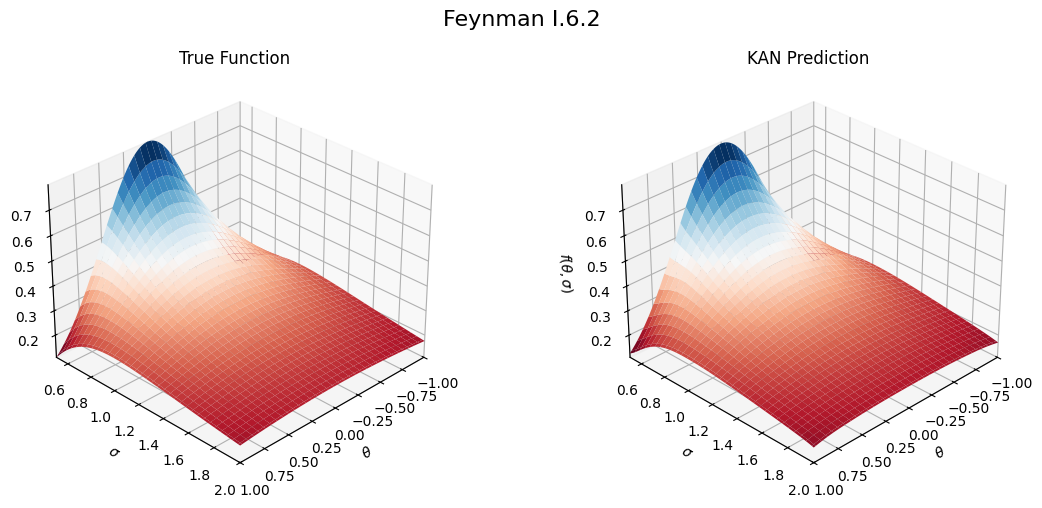

In [5]:
# Plot colormap
fig = plt.figure(figsize=(12,5))

# --- True function ---
ax1 = fig.add_subplot(121, projection='3d')
surf1 = ax1.plot_surface(X1_grid, X2_grid, Z_true, cmap='RdBu')

ax1.set_title("True Function")
ax1.set_xlabel("$\\theta$")
ax1.set_ylabel("$\\sigma$")

# --- KAN prediction ---
ax2 = fig.add_subplot(122, projection='3d')
surf2 = ax2.plot_surface(X1_grid, X2_grid, Z_pred, cmap='RdBu')

ax2.set_title("KAN Prediction")
ax2.set_xlabel("$\\theta$")
ax2.set_ylabel("$\\sigma$")
ax2.set_zlabel("$f(\\theta, \\sigma)$")

# --- Make axes identical ---
zmin = min(Z_true.min(), Z_pred.min())
zmax = max(Z_true.max(), Z_pred.max())

for ax in [ax1, ax2]:
    ax.set_xlim(-1, 1)
    ax.set_ylim(0.5, 2)
    ax.set_zlim(zmin, zmax)
    ax.view_init(elev=30, azim=45)

plt.suptitle("Feynman I.6.2", fontsize=16)
plt.tight_layout()
plt.show()

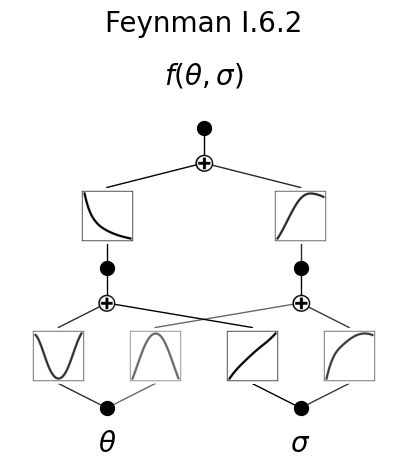

In [6]:
model_I_6_2.plot(in_vars=['$\\theta$', '$\\sigma$'], out_vars=['$f(\\theta, \\sigma)$'], title="Feynman I.6.2")

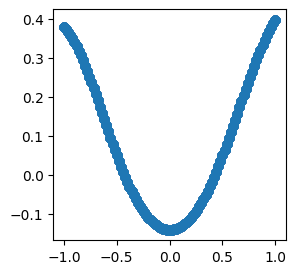

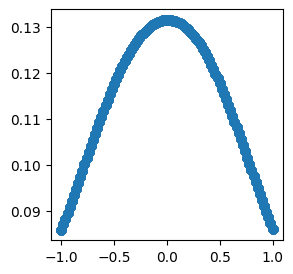

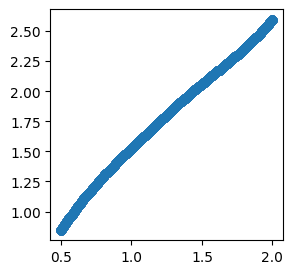

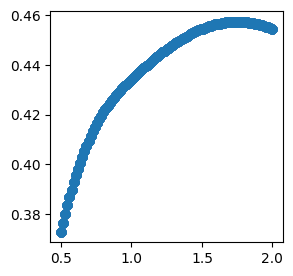

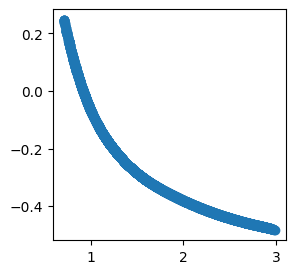

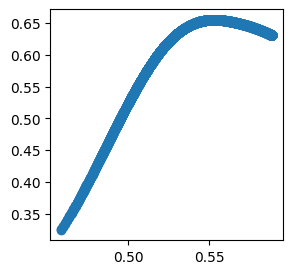

In [7]:
# label: "var_name + #th entry + _in/_out"
theta0_in,theta0_out = model_I_6_2.get_fun(0,0,0)
theta1_in,theta1_out = model_I_6_2.get_fun(0,0,1)
sigma0_in,sigma0_out = model_I_6_2.get_fun(0,1,0)
sigma1_in,sigma1_out = model_I_6_2.get_fun(0,1,1)
# label: "node + #th layer + _#th node + _in/_out"
node1_0_in, node1_0_out = model_I_6_2.get_fun(1,0,0)
node1_1_in,node1_1_out = model_I_6_2.get_fun(1,1,0)

In [8]:
# input
theta0_range = model_I_6_2.get_range(0,0,0)
theta1_range = model_I_6_2.get_range(0,0,1)
sigma0_range = model_I_6_2.get_range(0,1,0)
sigma1_range = model_I_6_2.get_range(0,1,1)
# 1st layer
node1_0_range = model_I_6_2.get_range(1,0,0)
node1_1_range = model_I_6_2.get_range(1,1,0)

# model.get_range(l,i,j) returns a tupe
#   (input_min, input_max, output_min, output_max)  all items stored as nparrays
#   .item() to convert a single value nparray to a float

x range: [-1.00 , 1.00 ]
y range: [-0.14 , 0.40 ]
x range: [-1.00 , 1.00 ]
y range: [0.09 , 0.13 ]
x range: [0.50 , 2.00 ]
y range: [0.85 , 2.59 ]
x range: [0.50 , 2.00 ]
y range: [0.37 , 0.46 ]
x range: [0.71 , 2.99 ]
y range: [-0.48 , 0.25 ]
x range: [0.46 , 0.59 ]
y range: [0.32 , 0.66 ]


In [9]:
os.makedirs("KAN_Feynman_activation_funcs/Feynman_I_6_2", exist_ok=True)
with open("KAN_Feynman_activation_funcs/Feynman_I_6_2/theta0.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(theta0_in, theta0_out)))

with open("KAN_Feynman_activation_funcs/Feynman_I_6_2/theta1.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(theta1_in, theta1_out)))

with open("KAN_Feynman_activation_funcs/Feynman_I_6_2/sigma0.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(sigma0_in, sigma0_out)))

with open("KAN_Feynman_activation_funcs/Feynman_I_6_2/sigma1.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(sigma1_in, sigma1_out)))

with open("KAN_Feynman_activation_funcs/Feynman_I_6_2/node1_0.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(node1_0_in, node1_0_out)))

with open("KAN_Feynman_activation_funcs/Feynman_I_6_2/node1_1.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(node1_1_in, node1_1_out)))


In [10]:
activation_functions = {
    'theta0': np.column_stack((theta0_in, theta0_out)),
    #'theta1': np.column_stack((theta1_in, theta1_out)),
    #'sigma0': np.column_stack((sigma0_in, sigma0_out)),
    #'sigma1': np.column_stack((sigma1_in, sigma1_out)),
    #'node1_0': np.column_stack((node1_0_in, node1_0_out)),
    #'node1_1': np.column_stack((node1_1_in, node1_1_out))
}

--- Benchmarking: 0G + 2S vs Splines (Smoothing=0.005) ---
Mixture Params for theta0: [ 0.53784126 -1.          1.          0.53784126  1.          1.        ]
Bias: 1.0000, mean(y_true): 0.0827


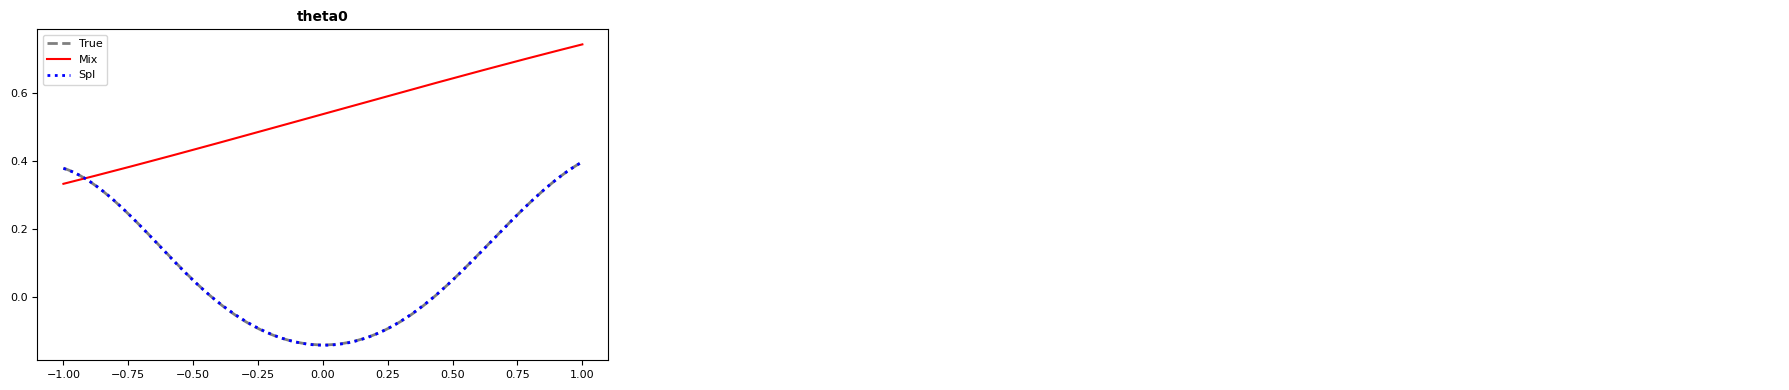


Equation                            | Mix MSE (Params)     | Spline MSE (Params)  | Winner
-----------------------------------------------------------------------------------------------
theta0                              | 2.5e-01 (7)          | 4.9e-07 (10)         | Spline


In [11]:
benchmark.run_benchmark(test_data=activation_functions, m=0, n=2, smoothing=0.005)

**Feynman I.12.11**

In [12]:
f_I_12_11 = lambda x: 1 + x[:,[0]] * torch.sin(x[:,[1]])
dataset = create_dataset(f_I_12_11, n_var=2, device=device, train_num=100, test_num=100, ranges=[[-1, 1], [0, 2*torch.pi]])

model_I_12_11 = KAN(width=[2,2,1], grid=3, k=3, seed=1, device=device)

checkpoint directory created: ./model
saving model version 0.0


In [13]:
model_I_12_11.fit(dataset, opt="LBFGS", steps=2000) #lr=1   # or opt="Adam"

| train_loss: 2.29e-03 | test_loss: 3.73e-03 | reg: 8.46e+00 | : 100%|█| 2000/2000 [00:15<00:00, 130


saving model version 0.1


{'train_loss': [array(0.23426083, dtype=float32),
  array(0.12723999, dtype=float32),
  array(0.08785203, dtype=float32),
  array(0.046563, dtype=float32),
  array(0.0399292, dtype=float32),
  array(0.0376446, dtype=float32),
  array(0.03417332, dtype=float32),
  array(0.03300481, dtype=float32),
  array(0.02959613, dtype=float32),
  array(0.02411546, dtype=float32),
  array(0.02224785, dtype=float32),
  array(0.02022376, dtype=float32),
  array(0.01886306, dtype=float32),
  array(0.01576267, dtype=float32),
  array(0.01462357, dtype=float32),
  array(0.01335395, dtype=float32),
  array(0.01240382, dtype=float32),
  array(0.0119469, dtype=float32),
  array(0.01123992, dtype=float32),
  array(0.00988225, dtype=float32),
  array(0.00878362, dtype=float32),
  array(0.00850335, dtype=float32),
  array(0.00803886, dtype=float32),
  array(0.0076497, dtype=float32),
  array(0.00743025, dtype=float32),
  array(0.00704206, dtype=float32),
  array(0.00675567, dtype=float32),
  array(0.00649967, 

In [14]:
a_grid = np.linspace(-1, 1, 101)
theta_grid = np.linspace(0, 2*torch.pi, 101)

X1_grid, X2_grid = np.meshgrid(a_grid, theta_grid)

# Convert grid to tensor input
grid_points = torch.tensor(
    np.stack([X1_grid.ravel(), X2_grid.ravel()], axis=1),
    dtype=torch.float32,
    device=device
)

Z_true = f_I_12_11(grid_points).numpy().reshape(X1_grid.shape)

# Get model predictions
with torch.no_grad():       # temporarily disables gradient tracking
    Z_pred = model_I_12_11(grid_points).numpy()
    # use the trained model to predict for the 101x101 grid points

# Reshape to grid
Z_pred = Z_pred.reshape(X1_grid.shape)

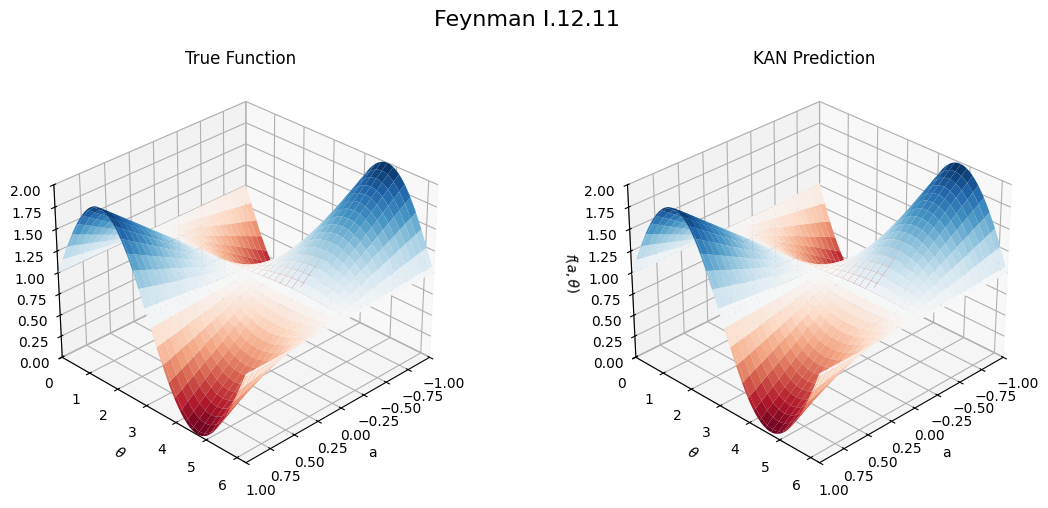

In [15]:
# Plot colormap
fig = plt.figure(figsize=(12,5))

# --- True function ---
ax1 = fig.add_subplot(121, projection='3d')
surf1 = ax1.plot_surface(X1_grid, X2_grid, Z_true, cmap='RdBu')

ax1.set_title("True Function")
ax1.set_xlabel("a")
ax1.set_ylabel("$\\theta$")

# --- KAN prediction ---
ax2 = fig.add_subplot(122, projection='3d')
surf2 = ax2.plot_surface(X1_grid, X2_grid, Z_pred, cmap='RdBu')

ax2.set_title("KAN Prediction")
ax2.set_xlabel("a")
ax2.set_ylabel("$\\theta$")
ax2.set_zlabel("$f(a, \\theta)$")

# --- Make axes identical ---
zmin = min(Z_true.min(), Z_pred.min())
zmax = max(Z_true.max(), Z_pred.max())

for ax in [ax1, ax2]:
    ax.set_xlim(-1, 1)
    ax.set_ylim(0, 2*torch.pi)
    ax.set_zlim(zmin, zmax)
    ax.view_init(elev=30, azim=45)

plt.suptitle("Feynman I.12.11", fontsize=16)
plt.tight_layout()
plt.show()

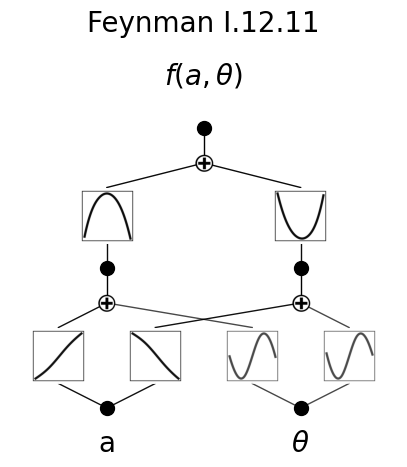

In [16]:
model_I_12_11.plot(in_vars=['a', '$\\theta$'], out_vars=['$f(a, \\theta)$'], title="Feynman I.12.11")

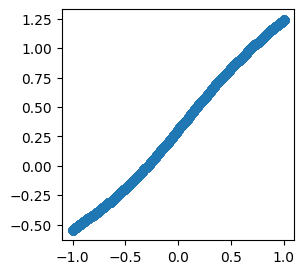

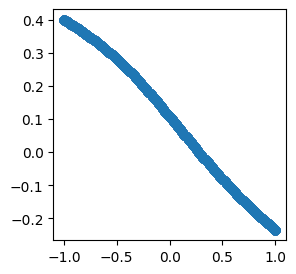

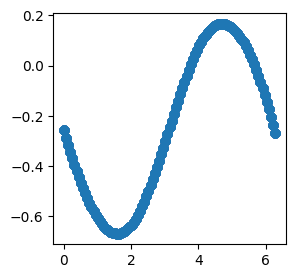

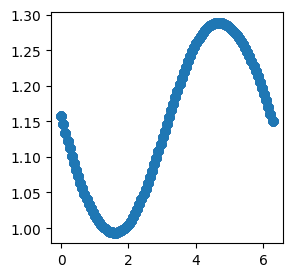

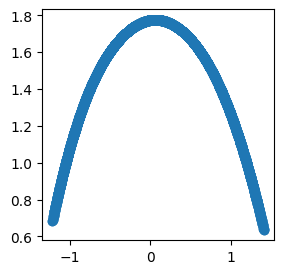

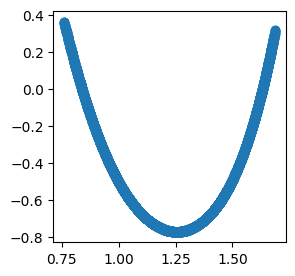

In [17]:
# label: "var_name + #th entry + _in/_out"
a0_in,a0_out = model_I_12_11.get_fun(0,0,0)
a1_in,a1_out = model_I_12_11.get_fun(0,0,1)
theta0_in,theta0_out = model_I_12_11.get_fun(0,1,0)
theta1_in,theta1_out = model_I_12_11.get_fun(0,1,1)
# label: "node + #th layer + _#th node + _in/_out"
node1_0_in, node1_0_out = model_I_12_11.get_fun(1,0,0)
node1_1_in,node1_1_out = model_I_12_11.get_fun(1,1,0)

In [18]:
os.makedirs("KAN_Feynman_activation_funcs/Feynman_I_12_11", exist_ok=True)
with open("KAN_Feynman_activation_funcs/Feynman_I_12_11/a0.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(a0_in, a0_out)))

with open("KAN_Feynman_activation_funcs/Feynman_I_12_11/a1.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(a1_in, a1_out)))

with open("KAN_Feynman_activation_funcs/Feynman_I_12_11/theta0.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(theta0_in, theta0_out)))

with open("KAN_Feynman_activation_funcs/Feynman_I_12_11/theta1.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(theta1_in, theta1_out)))

with open("KAN_Feynman_activation_funcs/Feynman_I_12_11/node1_0.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(node1_0_in, node1_0_out)))

with open("KAN_Feynman_activation_funcs/Feynman_I_12_11/node1_1.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(node1_1_in, node1_1_out)))


**Feynman I.13.12**

In [20]:
f_I_13_12 = lambda x: x[:,[0]]*(1/x[:,[1]] - 1)
dataset = create_dataset(f_I_13_12, n_var=2, device=device, train_num=100, test_num=100, ranges=[[0, 1], [0.5, 2]])

model_I_13_12 = KAN(width=[2,2,1], grid=3, k=3, seed=1, device=device)

checkpoint directory created: ./model
saving model version 0.0


In [21]:
model_I_13_12.fit(dataset, opt="LBFGS", steps=2000) #lr=1   # or opt="Adam"

| train_loss: 2.59e-04 | test_loss: 6.54e-04 | reg: 8.14e+00 | : 100%|█| 2000/2000 [00:16<00:00, 119


saving model version 0.1


{'train_loss': [array(0.01653321, dtype=float32),
  array(0.00826274, dtype=float32),
  array(0.00524166, dtype=float32),
  array(0.00432476, dtype=float32),
  array(0.00370218, dtype=float32),
  array(0.00276426, dtype=float32),
  array(0.00258861, dtype=float32),
  array(0.00186702, dtype=float32),
  array(0.00175275, dtype=float32),
  array(0.00161131, dtype=float32),
  array(0.00150006, dtype=float32),
  array(0.00146333, dtype=float32),
  array(0.00141503, dtype=float32),
  array(0.00137765, dtype=float32),
  array(0.00132695, dtype=float32),
  array(0.00136632, dtype=float32),
  array(0.00129446, dtype=float32),
  array(0.00122085, dtype=float32),
  array(0.0011773, dtype=float32),
  array(0.00114026, dtype=float32),
  array(0.00113659, dtype=float32),
  array(0.00107068, dtype=float32),
  array(0.00104293, dtype=float32),
  array(0.00101451, dtype=float32),
  array(0.00096573, dtype=float32),
  array(0.00096618, dtype=float32),
  array(0.00089946, dtype=float32),
  array(0.00065

In [22]:
a_grid = np.linspace(0, 1, 101)
b_grid = np.linspace(0.5, 2, 101)

X1_grid, X2_grid = np.meshgrid(a_grid, b_grid)

# Convert grid to tensor input
grid_points = torch.tensor(
    np.stack([X1_grid.ravel(), X2_grid.ravel()], axis=1),
    dtype=torch.float32,
    device=device
)

Z_true = f_I_13_12(grid_points).numpy().reshape(X1_grid.shape)

# Get model predictions
with torch.no_grad():       # temporarily disables gradient tracking
    Z_pred = model_I_13_12(grid_points).numpy()
    # use the trained model to predict for the 101x101 grid points

# Reshape to grid
Z_pred = Z_pred.reshape(X1_grid.shape)

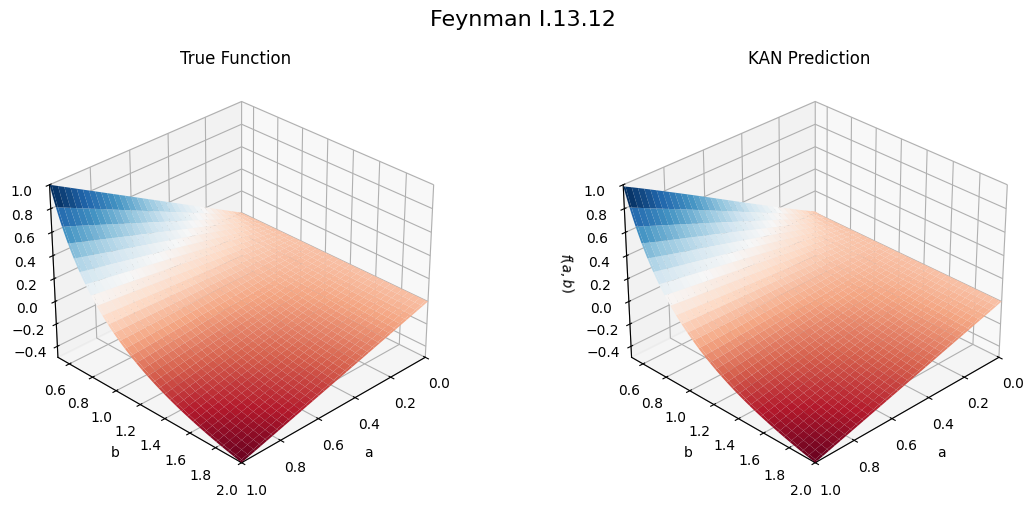

In [23]:
# Plot colormap
fig = plt.figure(figsize=(12,5))

# --- True function ---
ax1 = fig.add_subplot(121, projection='3d')
surf1 = ax1.plot_surface(X1_grid, X2_grid, Z_true, cmap='RdBu')

ax1.set_title("True Function")
ax1.set_xlabel("a")
ax1.set_ylabel("b")

# --- KAN prediction ---
ax2 = fig.add_subplot(122, projection='3d')
surf2 = ax2.plot_surface(X1_grid, X2_grid, Z_pred, cmap='RdBu')

ax2.set_title("KAN Prediction")
ax2.set_xlabel("a")
ax2.set_ylabel("b")
ax2.set_zlabel("$f(a, b)$")

# --- Make axes identical ---
zmin = min(Z_true.min(), Z_pred.min())
zmax = max(Z_true.max(), Z_pred.max())

for ax in [ax1, ax2]:
    ax.set_xlim(0, 1)
    ax.set_ylim(0.5, 2)
    ax.set_zlim(zmin, zmax)
    ax.view_init(elev=30, azim=45)

plt.suptitle("Feynman I.13.12", fontsize=16)
plt.tight_layout()
plt.show()

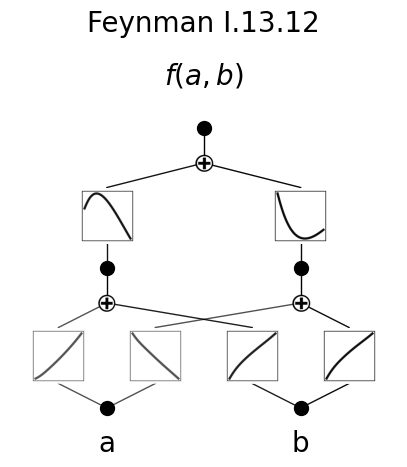

In [25]:
model_I_13_12.plot(in_vars=['a', 'b'], out_vars=['$f(a, b)$'], title="Feynman I.13.12")

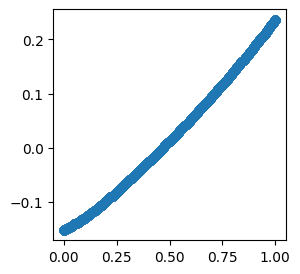

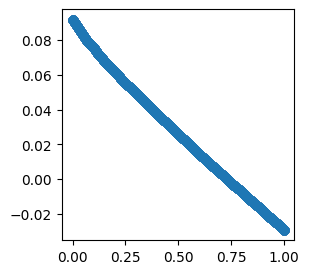

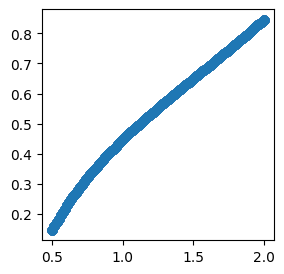

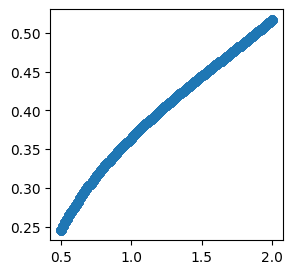

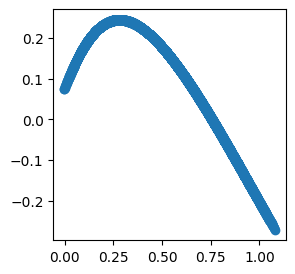

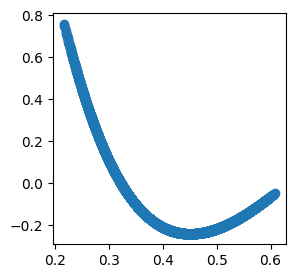

In [26]:
# label: "var_name + #th entry + _in/_out"
a0_in,a0_out = model_I_13_12.get_fun(0,0,0)
a1_in,a1_out = model_I_13_12.get_fun(0,0,1)
b0_in,b0_out = model_I_13_12.get_fun(0,1,0)
b1_in,b1_out = model_I_13_12.get_fun(0,1,1)
# label: "node + #th layer + _#th node + _in/_out"
node1_0_in, node1_0_out = model_I_13_12.get_fun(1,0,0)
node1_1_in,node1_1_out = model_I_13_12.get_fun(1,1,0)

In [27]:
os.makedirs("KAN_Feynman_activation_funcs/Feynman_I_13_12", exist_ok=True)
with open("KAN_Feynman_activation_funcs/Feynman_I_13_12/a0.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(a0_in, a0_out)))

with open("KAN_Feynman_activation_funcs/Feynman_I_13_12/a1.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(a1_in, a1_out)))

with open("KAN_Feynman_activation_funcs/Feynman_I_13_12/b0.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(b0_in, b0_out)))

with open("KAN_Feynman_activation_funcs/Feynman_I_13_12/b1.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(b1_in, b1_out)))

with open("KAN_Feynman_activation_funcs/Feynman_I_13_12/node1_0.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(node1_0_in, node1_0_out)))

with open("KAN_Feynman_activation_funcs/Feynman_I_13_12/node1_1.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(node1_1_in, node1_1_out)))


**Feynman I.15.3x**

In [28]:
f_I_15_3x = lambda x: (1-x[:,[0]])/ torch.sqrt(1 - x[:,[1]]**2)
dataset = create_dataset(f_I_15_3x, n_var=2, device=device, train_num=100, test_num=100, ranges=[[-1, 1], [-0.9, 0.9]])

model_I_15_3x = KAN(width=[2,1,1], grid=3, k=3, seed=1, device=device)

checkpoint directory created: ./model
saving model version 0.0


In [29]:
model_I_15_3x.fit(dataset, opt="LBFGS", steps=2000) #lr=1   # or opt="Adam"

| train_loss: 1.18e-02 | test_loss: 5.17e-02 | reg: 7.33e+00 | : 100%|█| 2000/2000 [00:13<00:00, 153


saving model version 0.1


{'train_loss': [array(0.07466452, dtype=float32),
  array(0.05171086, dtype=float32),
  array(0.03174944, dtype=float32),
  array(0.01596393, dtype=float32),
  array(0.01513623, dtype=float32),
  array(0.02042478, dtype=float32),
  array(0.01980137, dtype=float32),
  array(0.01850378, dtype=float32),
  array(0.01393186, dtype=float32),
  array(0.01376721, dtype=float32),
  array(0.01318314, dtype=float32),
  array(0.01306046, dtype=float32),
  array(0.01275953, dtype=float32),
  array(0.01256004, dtype=float32),
  array(0.01249406, dtype=float32),
  array(0.01229272, dtype=float32),
  array(0.01220445, dtype=float32),
  array(0.01219782, dtype=float32),
  array(0.01219607, dtype=float32),
  array(0.01219577, dtype=float32),
  array(0.01221557, dtype=float32),
  array(0.0122093, dtype=float32),
  array(0.01220432, dtype=float32),
  array(0.01219739, dtype=float32),
  array(0.01219603, dtype=float32),
  array(0.01220542, dtype=float32),
  array(0.01220542, dtype=float32),
  array(0.01220

In [30]:
a_grid = np.linspace(-1, 1, 101)
b_grid = np.linspace(-0.9, 0.9, 101)

X1_grid, X2_grid = np.meshgrid(a_grid, b_grid)

# Convert grid to tensor input
grid_points = torch.tensor(
    np.stack([X1_grid.ravel(), X2_grid.ravel()], axis=1),
    dtype=torch.float32,
    device=device
)

Z_true = f_I_15_3x(grid_points).numpy().reshape(X1_grid.shape)

# Get model predictions
with torch.no_grad():       # temporarily disables gradient tracking
    Z_pred = model_I_15_3x(grid_points).numpy()
    # use the trained model to predict for the 101x101 grid points

# Reshape to grid
Z_pred = Z_pred.reshape(X1_grid.shape)

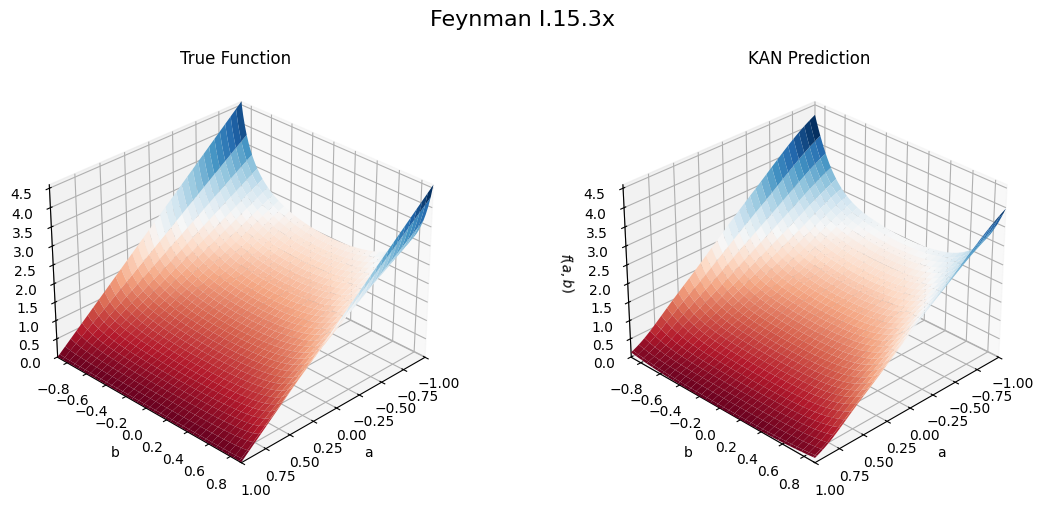

In [31]:
# Plot colormap
fig = plt.figure(figsize=(12,5))

# --- True function ---
ax1 = fig.add_subplot(121, projection='3d')
surf1 = ax1.plot_surface(X1_grid, X2_grid, Z_true, cmap='RdBu')

ax1.set_title("True Function")
ax1.set_xlabel("a")
ax1.set_ylabel("b")

# --- KAN prediction ---
ax2 = fig.add_subplot(122, projection='3d')
surf2 = ax2.plot_surface(X1_grid, X2_grid, Z_pred, cmap='RdBu')

ax2.set_title("KAN Prediction")
ax2.set_xlabel("a")
ax2.set_ylabel("b")
ax2.set_zlabel("$f(a, b)$")

# --- Make axes identical ---
zmin = min(Z_true.min(), Z_pred.min())
zmax = max(Z_true.max(), Z_pred.max())

for ax in [ax1, ax2]:
    ax.set_xlim(-1, 1)
    ax.set_ylim(-0.9, 0.9)
    ax.set_zlim(zmin, zmax)
    ax.view_init(elev=30, azim=45)

plt.suptitle("Feynman I.15.3x", fontsize=16)
plt.tight_layout()
plt.show()

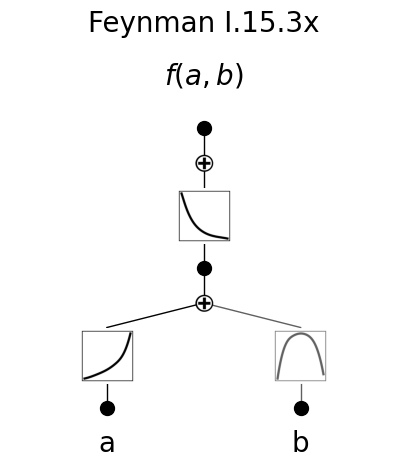

In [32]:
model_I_15_3x.plot(in_vars=['a', 'b'], out_vars=['$f(a, b)$'], title="Feynman I.15.3x")

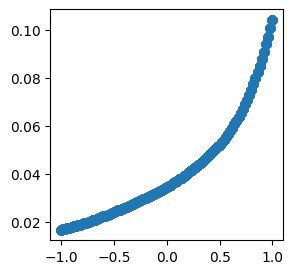

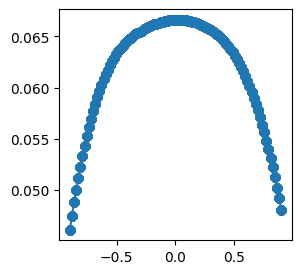

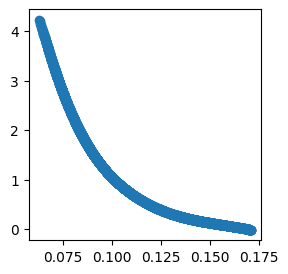

In [33]:
# label: "var_name + #th entry + _in/_out"
a0_in,a0_out = model_I_15_3x.get_fun(0,0,0)
b0_in,b0_out = model_I_15_3x.get_fun(0,1,0)
# label: "node + #th layer + _#th node + _in/_out"
node1_0_in, node1_0_out = model_I_15_3x.get_fun(1,0,0)

In [34]:
os.makedirs("KAN_Feynman_activation_funcs/Feynman_I_15_3x", exist_ok=True)
with open("KAN_Feynman_activation_funcs/Feynman_I_15_3x/a0.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(a0_in, a0_out)))

with open("KAN_Feynman_activation_funcs/Feynman_I_15_3x/b0.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(b0_in, b0_out)))

with open("KAN_Feynman_activation_funcs/Feynman_I_15_3x/node1_0.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(node1_0_in, node1_0_out)))


**Feynman I.16.6**

In [35]:
f_I_16_6 = lambda x: (x[:,[0]]+x[:,[1]]) / (1 + x[:,[0]]*x[:,[1]])
dataset = create_dataset(f_I_16_6, n_var=2, device=device, train_num=100, test_num=100, ranges=[[-0.8, 0.8], [-0.8, 0.8]])

model_I_16_6 = KAN(width=[2,2,1], grid=3, k=3, seed=1, device=device)

checkpoint directory created: ./model
saving model version 0.0


In [36]:
model_I_16_6.fit(dataset, opt="LBFGS", steps=2000) #lr=1   # or opt="Adam"

| train_loss: 1.32e-03 | test_loss: 3.43e-03 | reg: 8.67e+00 | : 100%|█| 2000/2000 [00:16<00:00, 118


saving model version 0.1


{'train_loss': [array(0.03218645, dtype=float32),
  array(0.01768383, dtype=float32),
  array(0.01164571, dtype=float32),
  array(0.01057865, dtype=float32),
  array(0.00937535, dtype=float32),
  array(0.00886363, dtype=float32),
  array(0.0054938, dtype=float32),
  array(0.00434506, dtype=float32),
  array(0.00343724, dtype=float32),
  array(0.00308289, dtype=float32),
  array(0.00327878, dtype=float32),
  array(0.00308042, dtype=float32),
  array(0.00291898, dtype=float32),
  array(0.00282597, dtype=float32),
  array(0.00271766, dtype=float32),
  array(0.00299806, dtype=float32),
  array(0.00271796, dtype=float32),
  array(0.00245444, dtype=float32),
  array(0.00224347, dtype=float32),
  array(0.00208206, dtype=float32),
  array(0.0027303, dtype=float32),
  array(0.00240647, dtype=float32),
  array(0.00206418, dtype=float32),
  array(0.00193242, dtype=float32),
  array(0.00189278, dtype=float32),
  array(0.00267062, dtype=float32),
  array(0.0025588, dtype=float32),
  array(0.0025043

In [37]:
a_grid = np.linspace(-0.8, 0.8, 101)
b_grid = np.linspace(-0.8, 0.8, 101)

X1_grid, X2_grid = np.meshgrid(a_grid, b_grid)

# Convert grid to tensor input
grid_points = torch.tensor(
    np.stack([X1_grid.ravel(), X2_grid.ravel()], axis=1),
    dtype=torch.float32,
    device=device
)

Z_true = f_I_16_6(grid_points).numpy().reshape(X1_grid.shape)

# Get model predictions
with torch.no_grad():       # temporarily disables gradient tracking
    Z_pred = model_I_16_6(grid_points).numpy()
    # use the trained model to predict for the 101x101 grid points

# Reshape to grid
Z_pred = Z_pred.reshape(X1_grid.shape)

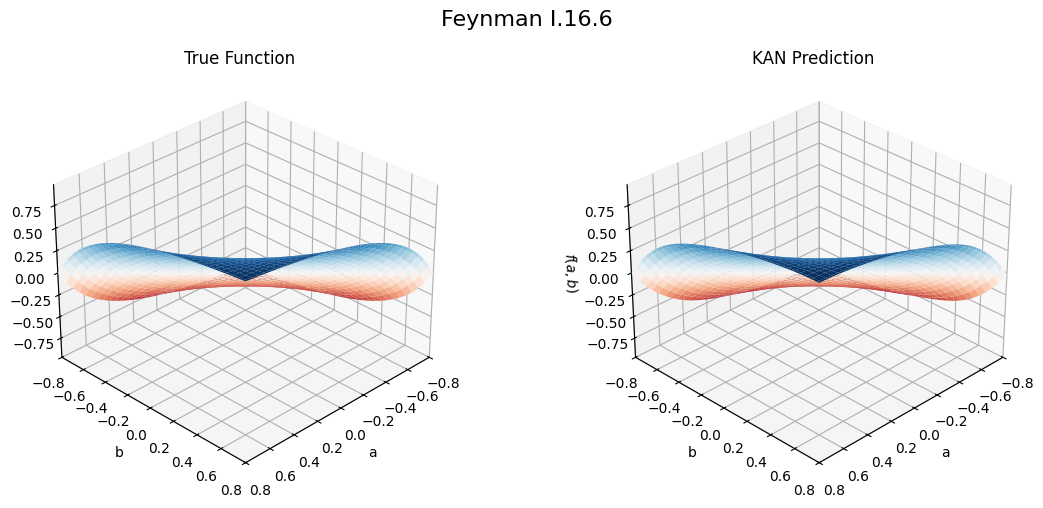

In [38]:
# Plot colormap
fig = plt.figure(figsize=(12,5))

# --- True function ---
ax1 = fig.add_subplot(121, projection='3d')
surf1 = ax1.plot_surface(X1_grid, X2_grid, Z_true, cmap='RdBu')

ax1.set_title("True Function")
ax1.set_xlabel("a")
ax1.set_ylabel("b")

# --- KAN prediction ---
ax2 = fig.add_subplot(122, projection='3d')
surf2 = ax2.plot_surface(X1_grid, X2_grid, Z_pred, cmap='RdBu')

ax2.set_title("KAN Prediction")
ax2.set_xlabel("a")
ax2.set_ylabel("b")
ax2.set_zlabel("$f(a, b)$")

# --- Make axes identical ---
zmin = min(Z_true.min(), Z_pred.min())
zmax = max(Z_true.max(), Z_pred.max())

for ax in [ax1, ax2]:
    ax.set_xlim(-0.8, 0.8)
    ax.set_ylim(-0.8, 0.8)
    ax.set_zlim(zmin, zmax)
    ax.view_init(elev=30, azim=45)

plt.suptitle("Feynman I.16.6", fontsize=16)
plt.tight_layout()
plt.show()

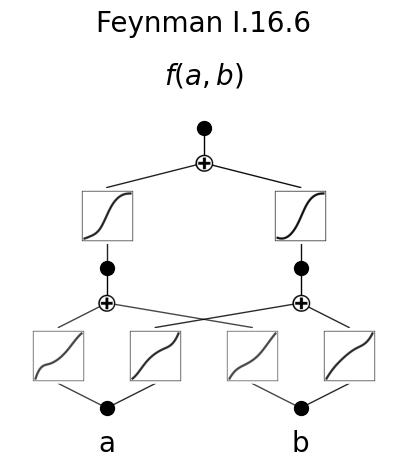

In [39]:
model_I_16_6.plot(in_vars=['a', 'b'], out_vars=['$f(a, b)$'], title="Feynman I.16.6")

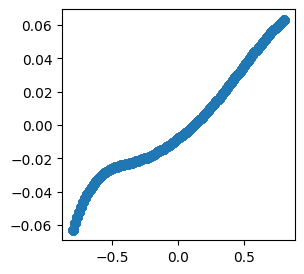

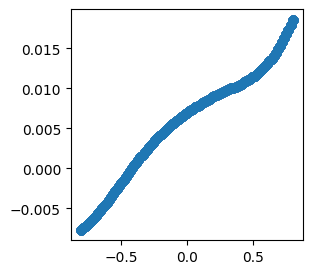

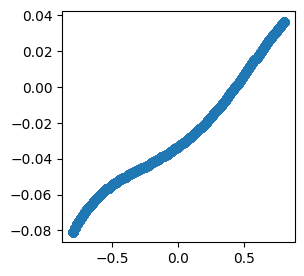

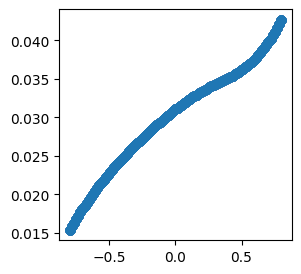

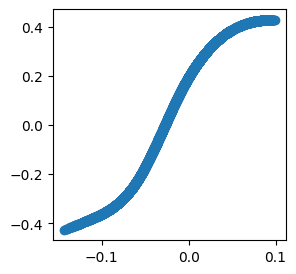

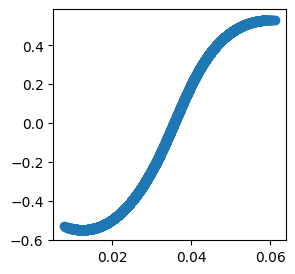

In [40]:
# label: "var_name + #th entry + _in/_out"
a0_in,a0_out = model_I_16_6.get_fun(0,0,0)
a1_in,a1_out = model_I_16_6.get_fun(0,0,1)
b0_in,b0_out = model_I_16_6.get_fun(0,1,0)
b1_in,b1_out = model_I_16_6.get_fun(0,1,1)
# label: "node + #th layer + _#th node + _in/_out"
node1_0_in, node1_0_out = model_I_16_6.get_fun(1,0,0)
node1_1_in,node1_1_out = model_I_16_6.get_fun(1,1,0)

In [41]:
os.makedirs("KAN_Feynman_activation_funcs/Feynman_I_16_6", exist_ok=True)
with open("KAN_Feynman_activation_funcs/Feynman_I_16_6/a0.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(a0_in, a0_out)))

with open("KAN_Feynman_activation_funcs/Feynman_I_16_6/a1.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(a1_in, a1_out)))

with open("KAN_Feynman_activation_funcs/Feynman_I_16_6/b0.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(b0_in, b0_out)))

with open("KAN_Feynman_activation_funcs/Feynman_I_16_6/b1.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(b1_in, b1_out)))

with open("KAN_Feynman_activation_funcs/Feynman_I_16_6/node1_0.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(node1_0_in, node1_0_out)))

with open("KAN_Feynman_activation_funcs/Feynman_I_16_6/node1_1.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(node1_1_in, node1_1_out)))


**Feynman I.18.4**

In [42]:
f_I_18_4 = lambda x: (1 + x[:,[0]]*x[:,[1]]) / (1 + x[:,[0]])
dataset = create_dataset(f_I_18_4, n_var=2, device=device, train_num=100, test_num=100, ranges=[[0.5, 2], [-1, 1]])

model_I_18_4 = KAN(width=[2,2,1], grid=3, k=3, seed=1, device=device)

checkpoint directory created: ./model
saving model version 0.0


In [43]:
model_I_18_4.fit(dataset, opt="LBFGS", steps=2000) #lr=1   # or opt="Adam"

| train_loss: 2.00e-04 | test_loss: 2.81e-04 | reg: 6.87e+00 | : 100%|█| 2000/2000 [00:15<00:00, 125


saving model version 0.1


{'train_loss': [array(0.04443297, dtype=float32),
  array(0.01585521, dtype=float32),
  array(0.01101075, dtype=float32),
  array(0.00601864, dtype=float32),
  array(0.00434843, dtype=float32),
  array(0.00294037, dtype=float32),
  array(0.00257626, dtype=float32),
  array(0.00222906, dtype=float32),
  array(0.00205672, dtype=float32),
  array(0.00194541, dtype=float32),
  array(0.00181472, dtype=float32),
  array(0.00140704, dtype=float32),
  array(0.00127485, dtype=float32),
  array(0.0012311, dtype=float32),
  array(0.00119254, dtype=float32),
  array(0.00119937, dtype=float32),
  array(0.00112534, dtype=float32),
  array(0.00106402, dtype=float32),
  array(0.00101994, dtype=float32),
  array(0.00094896, dtype=float32),
  array(0.00091743, dtype=float32),
  array(0.0008859, dtype=float32),
  array(0.00084187, dtype=float32),
  array(0.00077869, dtype=float32),
  array(0.0007487, dtype=float32),
  array(0.00076618, dtype=float32),
  array(0.00074893, dtype=float32),
  array(0.0007435

In [44]:
a_grid = np.linspace(0.5, 2, 101)
b_grid = np.linspace(-1, 1, 101)

X1_grid, X2_grid = np.meshgrid(a_grid, b_grid)

# Convert grid to tensor input
grid_points = torch.tensor(
    np.stack([X1_grid.ravel(), X2_grid.ravel()], axis=1),
    dtype=torch.float32,
    device=device
)

Z_true = f_I_18_4(grid_points).numpy().reshape(X1_grid.shape)

# Get model predictions
with torch.no_grad():       # temporarily disables gradient tracking
    Z_pred = model_I_18_4(grid_points).numpy()
    # use the trained model to predict for the 101x101 grid points

# Reshape to grid
Z_pred = Z_pred.reshape(X1_grid.shape)

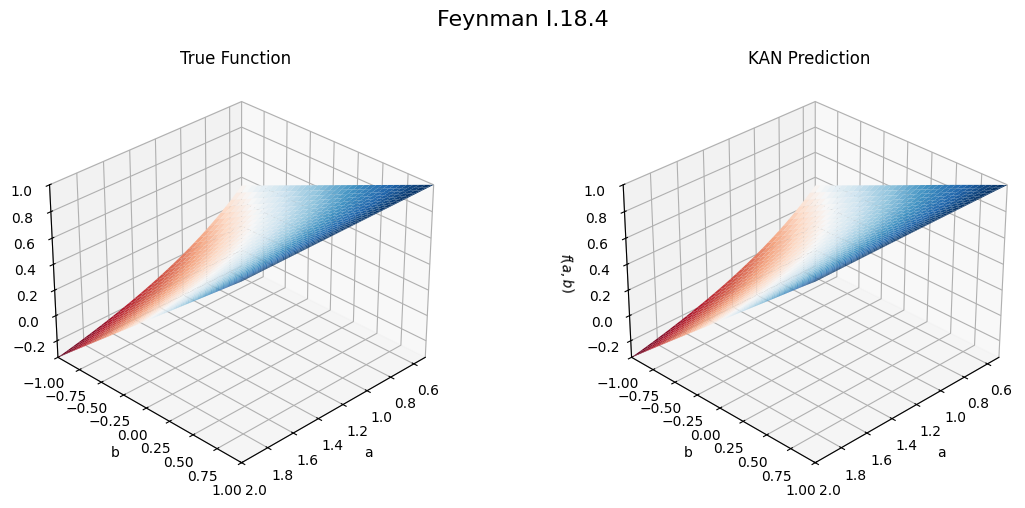

In [45]:
# Plot colormap
fig = plt.figure(figsize=(12,5))

# --- True function ---
ax1 = fig.add_subplot(121, projection='3d')
surf1 = ax1.plot_surface(X1_grid, X2_grid, Z_true, cmap='RdBu')

ax1.set_title("True Function")
ax1.set_xlabel("a")
ax1.set_ylabel("b")

# --- KAN prediction ---
ax2 = fig.add_subplot(122, projection='3d')
surf2 = ax2.plot_surface(X1_grid, X2_grid, Z_pred, cmap='RdBu')

ax2.set_title("KAN Prediction")
ax2.set_xlabel("a")
ax2.set_ylabel("b")
ax2.set_zlabel("$f(a, b)$")

# --- Make axes identical ---
zmin = min(Z_true.min(), Z_pred.min())
zmax = max(Z_true.max(), Z_pred.max())

for ax in [ax1, ax2]:
    ax.set_xlim(0.5, 2)
    ax.set_ylim(-1, 1)
    ax.set_zlim(zmin, zmax)
    ax.view_init(elev=30, azim=45)

plt.suptitle("Feynman I.18.4", fontsize=16)
plt.tight_layout()
plt.show()

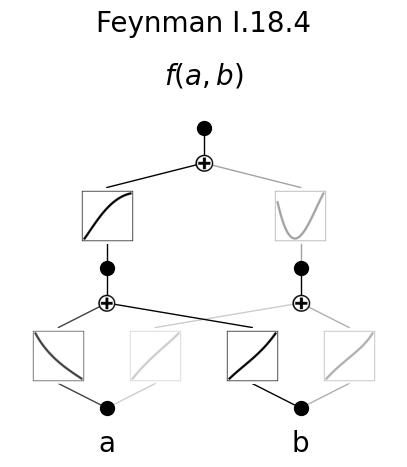

In [46]:
model_I_18_4.plot(in_vars=['a', 'b'], out_vars=['$f(a, b)$'], title="Feynman I.18.4")

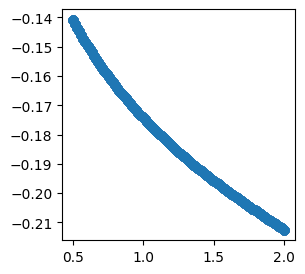

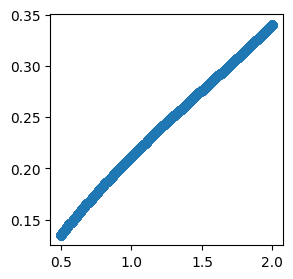

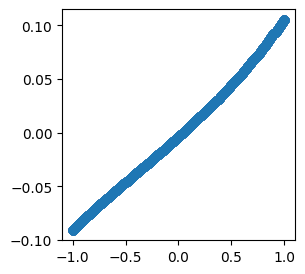

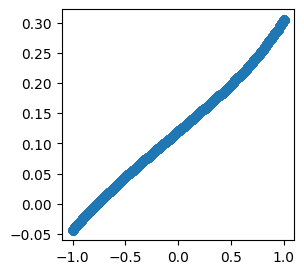

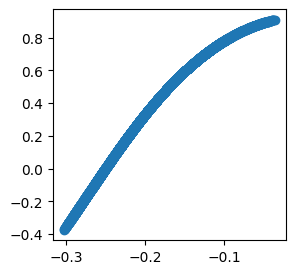

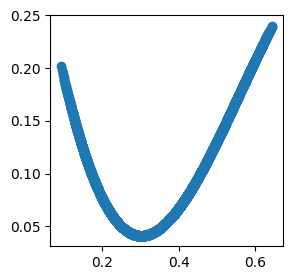

In [47]:
# label: "var_name + #th entry + _in/_out"
a0_in,a0_out = model_I_18_4.get_fun(0,0,0)
a1_in,a1_out = model_I_18_4.get_fun(0,0,1)
b0_in,b0_out = model_I_18_4.get_fun(0,1,0)
b1_in,b1_out = model_I_18_4.get_fun(0,1,1)
# label: "node + #th layer + _#th node + _in/_out"
node1_0_in, node1_0_out = model_I_18_4.get_fun(1,0,0)
node1_1_in,node1_1_out = model_I_18_4.get_fun(1,1,0)

In [48]:
os.makedirs("KAN_Feynman_activation_funcs/Feynman_I_18_4", exist_ok=True)
with open("KAN_Feynman_activation_funcs/Feynman_I_18_4/a0.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(a0_in, a0_out)))

with open("KAN_Feynman_activation_funcs/Feynman_I_18_4/a1.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(a1_in, a1_out)))

with open("KAN_Feynman_activation_funcs/Feynman_I_18_4/b0.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(b0_in, b0_out)))

with open("KAN_Feynman_activation_funcs/Feynman_I_18_4/b1.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(b1_in, b1_out)))

with open("KAN_Feynman_activation_funcs/Feynman_I_18_4/node1_0.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(node1_0_in, node1_0_out)))

with open("KAN_Feynman_activation_funcs/Feynman_I_18_4/node1_1.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(node1_1_in, node1_1_out)))


**Feynman I.26.2**

In [49]:
f_I_26_2 = lambda x: torch.arcsin(x[:,[0]] * torch.sin(x[:,[1]]))
dataset = create_dataset(f_I_26_2, n_var=2, device=device, train_num=100, test_num=100, ranges=[[0, 0.99], [0, 2*torch.pi]])

model_I_26_2 = KAN(width=[2,2,1], grid=3, k=3, seed=1, device=device)

checkpoint directory created: ./model
saving model version 0.0


In [50]:
model_I_26_2.fit(dataset, opt="LBFGS", steps=2000) #lr=1   # or opt="Adam"

| train_loss: 5.73e-03 | test_loss: 1.62e-02 | reg: 9.49e+00 | : 100%|█| 2000/2000 [00:19<00:00, 105


saving model version 0.1


{'train_loss': [array(0.21981378, dtype=float32),
  array(0.09177017, dtype=float32),
  array(0.05009844, dtype=float32),
  array(0.02010924, dtype=float32),
  array(0.01564819, dtype=float32),
  array(0.02016425, dtype=float32),
  array(0.01800345, dtype=float32),
  array(0.01567581, dtype=float32),
  array(0.01491106, dtype=float32),
  array(0.01461072, dtype=float32),
  array(0.01414283, dtype=float32),
  array(0.01221391, dtype=float32),
  array(0.01075674, dtype=float32),
  array(0.00979288, dtype=float32),
  array(0.00949841, dtype=float32),
  array(0.01040089, dtype=float32),
  array(0.0093788, dtype=float32),
  array(0.00887177, dtype=float32),
  array(0.00880514, dtype=float32),
  array(0.00869003, dtype=float32),
  array(0.00892077, dtype=float32),
  array(0.0087273, dtype=float32),
  array(0.00859156, dtype=float32),
  array(0.00845324, dtype=float32),
  array(0.00836469, dtype=float32),
  array(0.00838058, dtype=float32),
  array(0.00828449, dtype=float32),
  array(0.008213

In [51]:
n_grid = np.linspace(0, 0.99, 101)
theta_grid = np.linspace(0, 2*torch.pi, 101)

X1_grid, X2_grid = np.meshgrid(n_grid, theta_grid)

# Convert grid to tensor input
grid_points = torch.tensor(
    np.stack([X1_grid.ravel(), X2_grid.ravel()], axis=1),
    dtype=torch.float32,
    device=device
)

Z_true = f_I_26_2(grid_points).numpy().reshape(X1_grid.shape)

# Get model predictions
with torch.no_grad():       # temporarily disables gradient tracking
    Z_pred = model_I_26_2(grid_points).numpy()
    # use the trained model to predict for the 101x101 grid points

# Reshape to grid
Z_pred = Z_pred.reshape(X1_grid.shape)

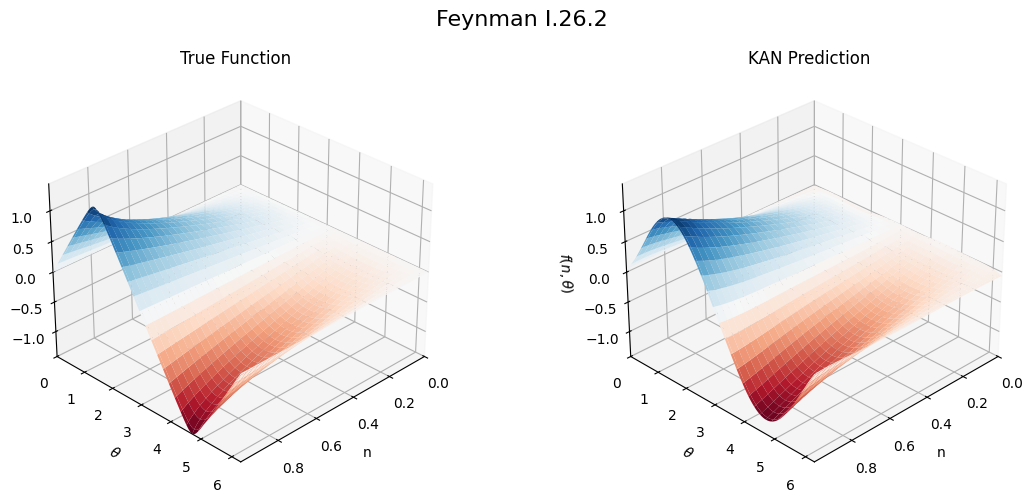

In [52]:
# Plot colormap
fig = plt.figure(figsize=(12,5))

# --- True function ---
ax1 = fig.add_subplot(121, projection='3d')
surf1 = ax1.plot_surface(X1_grid, X2_grid, Z_true, cmap='RdBu')

ax1.set_title("True Function")
ax1.set_xlabel("n")
ax1.set_ylabel("$\\theta$")

# --- KAN prediction ---
ax2 = fig.add_subplot(122, projection='3d')
surf2 = ax2.plot_surface(X1_grid, X2_grid, Z_pred, cmap='RdBu')

ax2.set_title("KAN Prediction")
ax2.set_xlabel("n")
ax2.set_ylabel("$\\theta$")
ax2.set_zlabel("$f(n, \\theta)$")

# --- Make axes identical ---
zmin = min(Z_true.min(), Z_pred.min())
zmax = max(Z_true.max(), Z_pred.max())

for ax in [ax1, ax2]:
    ax.set_xlim(0, 0.99)
    ax.set_ylim(0, 2*torch.pi)
    ax.set_zlim(zmin, zmax)
    ax.view_init(elev=30, azim=45)

plt.suptitle("Feynman I.26.2", fontsize=16)
plt.tight_layout()
plt.show()

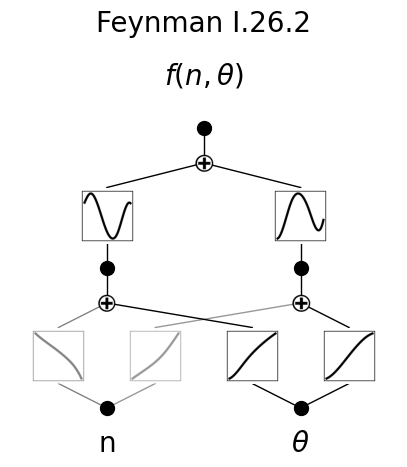

In [53]:
model_I_26_2.plot(in_vars=['n', '$\\theta$'], out_vars=['$f(n, \\theta)$'], title="Feynman I.26.2")

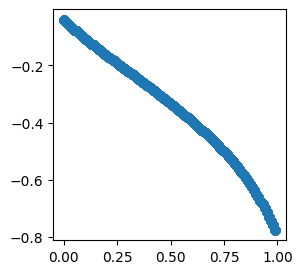

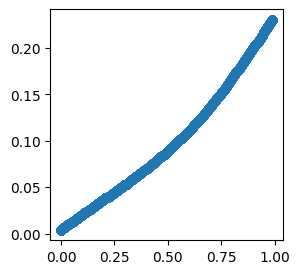

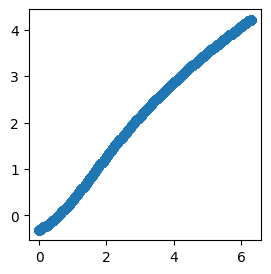

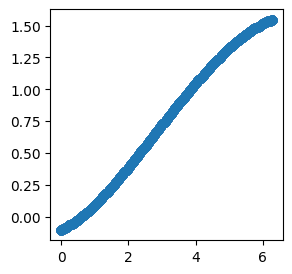

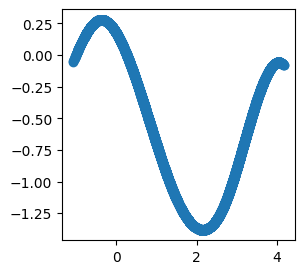

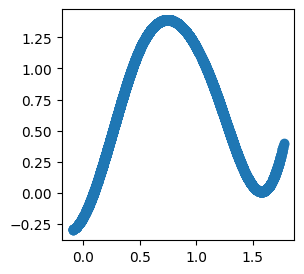

In [54]:
# label: "var_name + #th entry + _in/_out"
n0_in,n0_out = model_I_26_2.get_fun(0,0,0)
n1_in,n1_out = model_I_26_2.get_fun(0,0,1)
theta0_in,theta0_out = model_I_26_2.get_fun(0,1,0)
theta1_in,theta1_out = model_I_26_2.get_fun(0,1,1)
# label: "node + #th layer + _#th node + _in/_out"
node1_0_in, node1_0_out = model_I_26_2.get_fun(1,0,0)
node1_1_in,node1_1_out = model_I_26_2.get_fun(1,1,0)

In [55]:
os.makedirs("KAN_Feynman_activation_funcs/Feynman_I_26_2", exist_ok=True)
with open("KAN_Feynman_activation_funcs/Feynman_I_26_2/n0.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(n0_in, n0_out)))

with open("KAN_Feynman_activation_funcs/Feynman_I_26_2/n1.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(n1_in, n1_out)))

with open("KAN_Feynman_activation_funcs/Feynman_I_26_2/theta0.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(theta0_in, theta0_out)))

with open("KAN_Feynman_activation_funcs/Feynman_I_26_2/theta1.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(theta1_in, theta1_out)))

with open("KAN_Feynman_activation_funcs/Feynman_I_26_2/node1_0.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(node1_0_in, node1_0_out)))

with open("KAN_Feynman_activation_funcs/Feynman_I_26_2/node1_1.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(node1_1_in, node1_1_out)))


**Feynman I.27.6**

In [56]:
f_I_27_6 = lambda x: 1/(1 + x[:,[0]]*x[:,[1]])
dataset = create_dataset(f_I_27_6, n_var=2, device=device, train_num=100, test_num=100, ranges=[[0.25, 2], [0.5, 2]])

model_I_27_6 = KAN(width=[2,1,1], grid=3, k=3, seed=1, device=device)

checkpoint directory created: ./model
saving model version 0.0


In [57]:
model_I_27_6.fit(dataset, opt="LBFGS", steps=2000) #lr=1   # or opt="Adam"

| train_loss: 4.10e-04 | test_loss: 1.12e-03 | reg: 4.26e+00 | : 100%|█| 2000/2000 [00:13<00:00, 151


saving model version 0.1


{'train_loss': [array(0.01326645, dtype=float32),
  array(0.00765533, dtype=float32),
  array(0.00325429, dtype=float32),
  array(0.00149804, dtype=float32),
  array(0.00138678, dtype=float32),
  array(0.00084479, dtype=float32),
  array(0.00056756, dtype=float32),
  array(0.00055213, dtype=float32),
  array(0.00047253, dtype=float32),
  array(0.00043569, dtype=float32),
  array(0.00043248, dtype=float32),
  array(0.0004271, dtype=float32),
  array(0.00042268, dtype=float32),
  array(0.00042057, dtype=float32),
  array(0.00041761, dtype=float32),
  array(0.00041596, dtype=float32),
  array(0.00041372, dtype=float32),
  array(0.00041045, dtype=float32),
  array(0.00040925, dtype=float32),
  array(0.00040924, dtype=float32),
  array(0.00041003, dtype=float32),
  array(0.00041002, dtype=float32),
  array(0.00041002, dtype=float32),
  array(0.00041002, dtype=float32),
  array(0.00041002, dtype=float32),
  array(0.00041008, dtype=float32),
  array(0.00041008, dtype=float32),
  array(0.00041

In [58]:
a_grid = np.linspace(0.25, 2, 101)
b_grid = np.linspace(0.5, 2, 101)

X1_grid, X2_grid = np.meshgrid(a_grid, b_grid)

# Convert grid to tensor input
grid_points = torch.tensor(
    np.stack([X1_grid.ravel(), X2_grid.ravel()], axis=1),
    dtype=torch.float32,
    device=device
)

Z_true = f_I_27_6(grid_points).numpy().reshape(X1_grid.shape)

# Get model predictions
with torch.no_grad():       # temporarily disables gradient tracking
    Z_pred = model_I_27_6(grid_points).numpy()
    # use the trained model to predict for the 101x101 grid points

# Reshape to grid
Z_pred = Z_pred.reshape(X1_grid.shape)

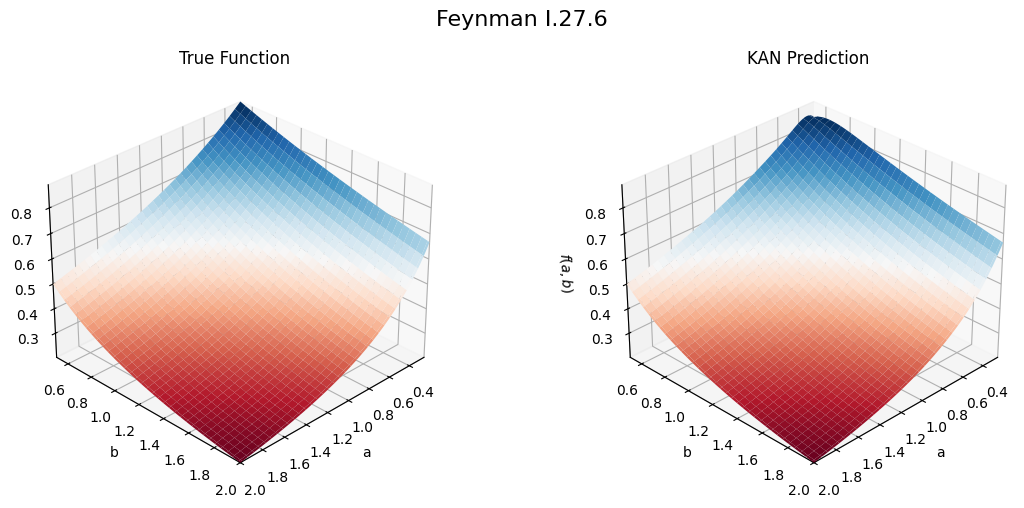

In [59]:
# Plot colormap
fig = plt.figure(figsize=(12,5))

# --- True function ---
ax1 = fig.add_subplot(121, projection='3d')
surf1 = ax1.plot_surface(X1_grid, X2_grid, Z_true, cmap='RdBu')

ax1.set_title("True Function")
ax1.set_xlabel("a")
ax1.set_ylabel("b")

# --- KAN prediction ---
ax2 = fig.add_subplot(122, projection='3d')
surf2 = ax2.plot_surface(X1_grid, X2_grid, Z_pred, cmap='RdBu')

ax2.set_title("KAN Prediction")
ax2.set_xlabel("a")
ax2.set_ylabel("b")
ax2.set_zlabel("$f(a, b)$")

# --- Make axes identical ---
zmin = min(Z_true.min(), Z_pred.min())
zmax = max(Z_true.max(), Z_pred.max())

for ax in [ax1, ax2]:
    ax.set_xlim(0.25, 2)
    ax.set_ylim(0.5, 2)
    ax.set_zlim(zmin, zmax)
    ax.view_init(elev=30, azim=45)

plt.suptitle("Feynman I.27.6", fontsize=16)
plt.tight_layout()
plt.show()

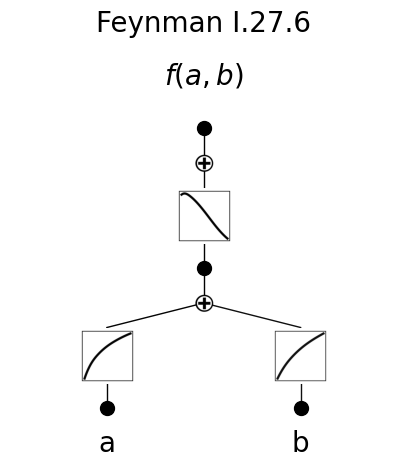

In [60]:
model_I_27_6.plot(in_vars=['a', 'b'], out_vars=['$f(a, b)$'], title="Feynman I.27.6")

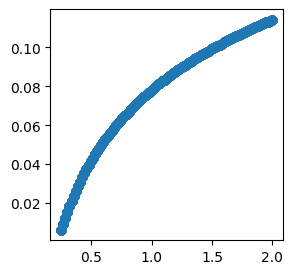

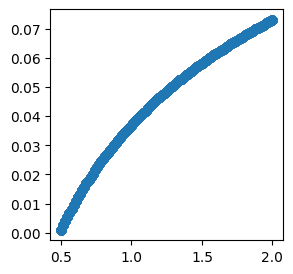

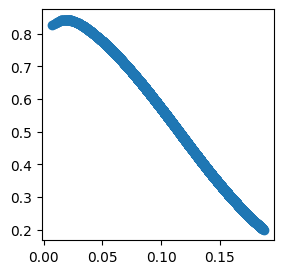

In [61]:
# label: "var_name + #th entry + _in/_out"
a0_in,a0_out = model_I_27_6.get_fun(0,0,0)
b0_in,b0_out = model_I_27_6.get_fun(0,1,0)
# label: "node + #th layer + _#th node + _in/_out"
node1_0_in, node1_0_out = model_I_27_6.get_fun(1,0,0)

In [62]:
os.makedirs("KAN_Feynman_activation_funcs/Feynman_I_27_6", exist_ok=True)
with open("KAN_Feynman_activation_funcs/Feynman_I_27_6/a0.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(a0_in, a0_out)))

with open("KAN_Feynman_activation_funcs/Feynman_I_27_6/b0.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(b0_in, b0_out)))

with open("KAN_Feynman_activation_funcs/Feynman_I_27_6/node1_0.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(node1_0_in, node1_0_out)))


**Feynman I.30.3**

In [63]:
f_I_30_3 = lambda x: torch.sin(x[:,[0]] * x[:,[1]] / 2) ** 2 / (torch.sin(x[:,[1]] / 2) ** 2)
dataset = create_dataset(f_I_30_3, n_var=2, device=device, train_num=100, test_num=100, ranges=[[0, 4], [0.4*torch.pi, 1.6*torch.pi]])

model_I_30_3 = KAN(width=[2,4,3,1], grid=3, k=3, seed=1, device=device)

checkpoint directory created: ./model
saving model version 0.0


In [64]:
model_I_30_3.fit(dataset, opt="LBFGS", steps=2000) #lr=1   # or opt="Adam"

| train_loss: 5.91e-03 | test_loss: 1.59e-01 | reg: 2.65e+01 | : 100%|█| 2000/2000 [00:41<00:00, 48.


saving model version 0.1


{'train_loss': [array(0.35261533, dtype=float32),
  array(0.2851449, dtype=float32),
  array(0.26639876, dtype=float32),
  array(0.23943245, dtype=float32),
  array(0.20094039, dtype=float32),
  array(0.2262068, dtype=float32),
  array(0.18072587, dtype=float32),
  array(0.15170531, dtype=float32),
  array(0.11388411, dtype=float32),
  array(0.09315109, dtype=float32),
  array(0.16238423, dtype=float32),
  array(0.13506903, dtype=float32),
  array(0.12011015, dtype=float32),
  array(0.11159632, dtype=float32),
  array(0.10612287, dtype=float32),
  array(0.1088175, dtype=float32),
  array(0.10383079, dtype=float32),
  array(0.09969194, dtype=float32),
  array(0.09632584, dtype=float32),
  array(0.09240717, dtype=float32),
  array(0.08918927, dtype=float32),
  array(0.08449619, dtype=float32),
  array(0.08149124, dtype=float32),
  array(0.07808965, dtype=float32),
  array(0.07477205, dtype=float32),
  array(0.07642934, dtype=float32),
  array(0.07354376, dtype=float32),
  array(0.0710232

In [65]:
n_grid = np.linspace(0, 4, 101)
theta_grid = np.linspace(0.4*torch.pi, 1.6*torch.pi, 101)

X1_grid, X2_grid = np.meshgrid(n_grid, theta_grid)

# Convert grid to tensor input
grid_points = torch.tensor(
    np.stack([X1_grid.ravel(), X2_grid.ravel()], axis=1),
    dtype=torch.float32,
    device=device
)

Z_true = f_I_30_3(grid_points).numpy().reshape(X1_grid.shape)

# Get model predictions
with torch.no_grad():       # temporarily disables gradient tracking
    Z_pred = model_I_30_3(grid_points).numpy()
    # use the trained model to predict for the 101x101 grid points

# Reshape to grid
Z_pred = Z_pred.reshape(X1_grid.shape)

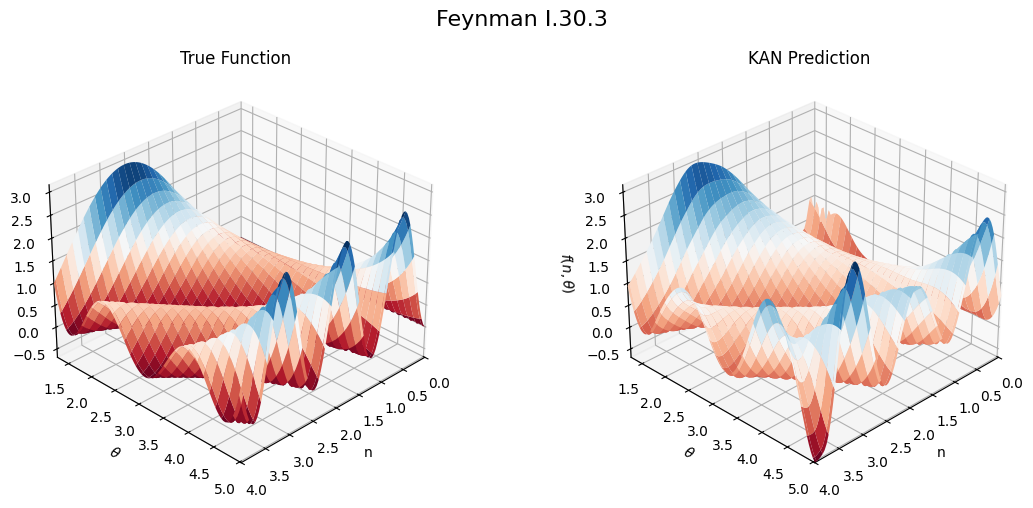

In [66]:
# Plot colormap
fig = plt.figure(figsize=(12,5))

# --- True function ---
ax1 = fig.add_subplot(121, projection='3d')
surf1 = ax1.plot_surface(X1_grid, X2_grid, Z_true, cmap='RdBu')

ax1.set_title("True Function")
ax1.set_xlabel("n")
ax1.set_ylabel("$\\theta$")

# --- KAN prediction ---
ax2 = fig.add_subplot(122, projection='3d')
surf2 = ax2.plot_surface(X1_grid, X2_grid, Z_pred, cmap='RdBu')

ax2.set_title("KAN Prediction")
ax2.set_xlabel("n")
ax2.set_ylabel("$\\theta$")
ax2.set_zlabel("$f(n, \\theta)$")

# --- Make axes identical ---
zmin = min(Z_true.min(), Z_pred.min())
zmax = max(Z_true.max(), Z_pred.max())

for ax in [ax1, ax2]:
    ax.set_xlim(0, 4)
    ax.set_ylim(0.4*torch.pi, 1.6*torch.pi)
    ax.set_zlim(zmin, zmax)
    ax.view_init(elev=30, azim=45)

plt.suptitle("Feynman I.30.3", fontsize=16)
plt.tight_layout()
plt.show()

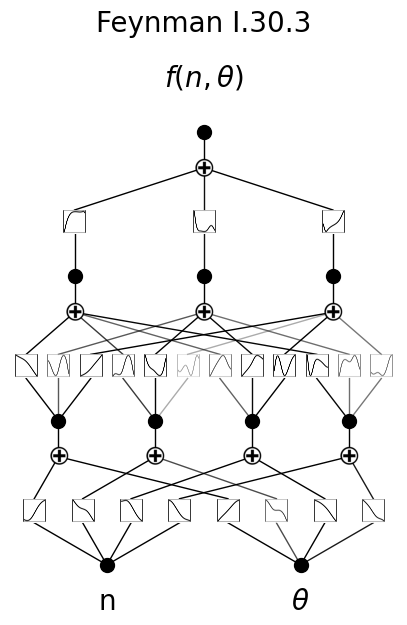

In [67]:
model_I_30_3.plot(in_vars=['n', '$\\theta$'], out_vars=['$f(n, \\theta)$'], title="Feynman I.30.3")

/Users/bessie/Library/Python/3.12/lib/python/site-packages/kan/MultKAN.py:2705: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(3,3))


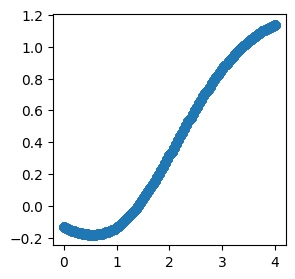

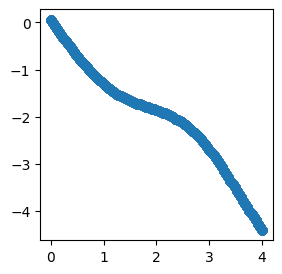

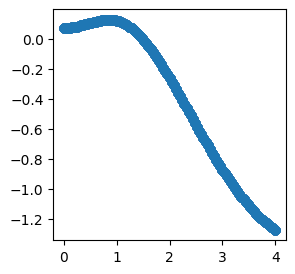

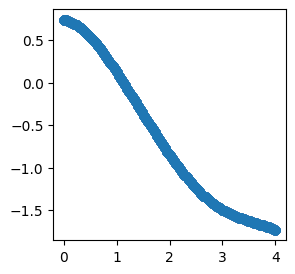

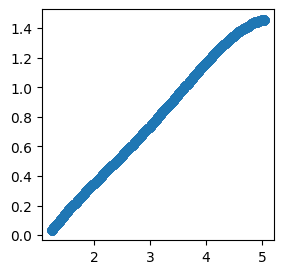

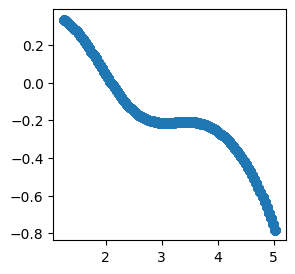

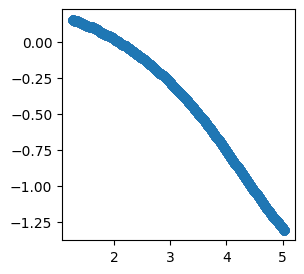

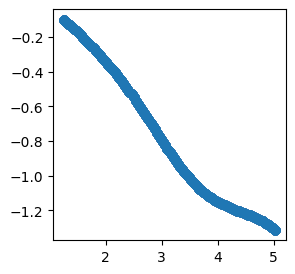

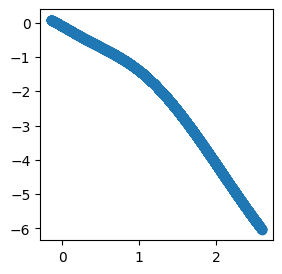

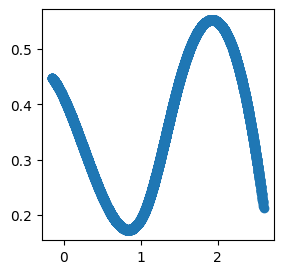

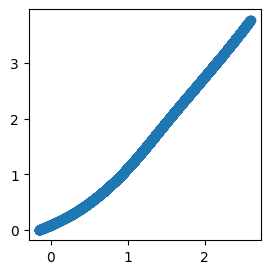

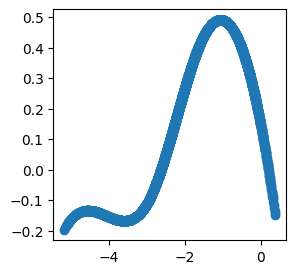

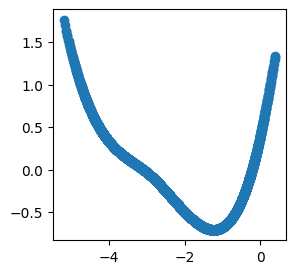

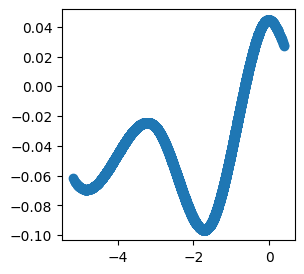

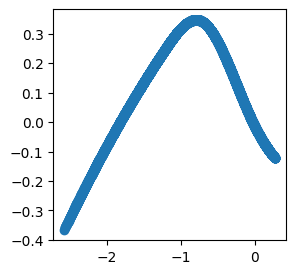

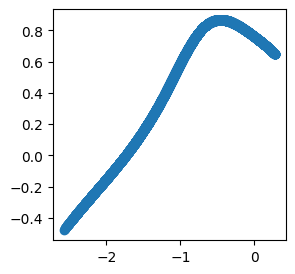

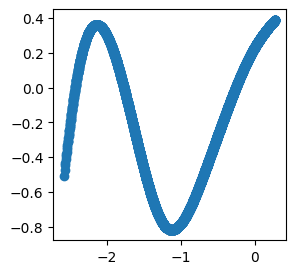

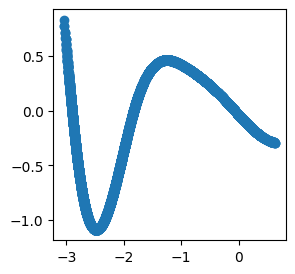

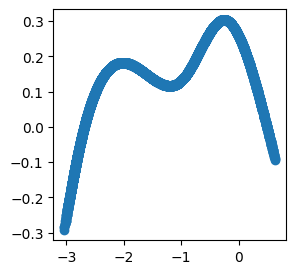

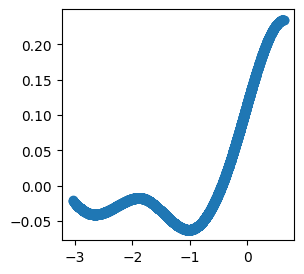

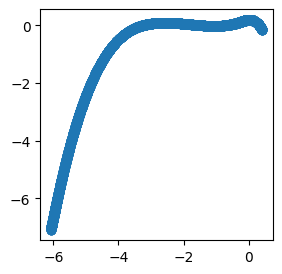

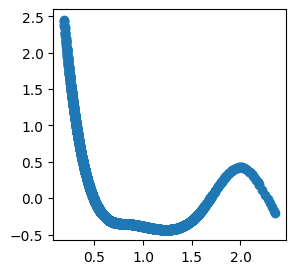

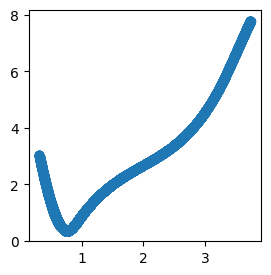

In [68]:
# label: "var_name + #th entry + _in/_out"
n0_in,n0_out = model_I_30_3.get_fun(0,0,0)
n1_in,n1_out = model_I_30_3.get_fun(0,0,1)
n2_in,n2_out = model_I_30_3.get_fun(0,0,2)
n3_in,n3_out = model_I_30_3.get_fun(0,0,3)

theta0_in,theta0_out = model_I_30_3.get_fun(0,1,0)
theta1_in,theta1_out = model_I_30_3.get_fun(0,1,1)
theta2_in,theta2_out = model_I_30_3.get_fun(0,1,2)
theta3_in,theta3_out = model_I_30_3.get_fun(0,1,3)

# label: "node + #th layer + _#th node + #th entry + _in/_out"
node1_0_0in, node1_0_0out = model_I_30_3.get_fun(1,0,0)
node1_0_1in, node1_0_1out = model_I_30_3.get_fun(1,0,1)
node1_0_2in, node1_0_2out = model_I_30_3.get_fun(1,0,2)

node1_1_0in, node1_1_0out = model_I_30_3.get_fun(1,1,0)
node1_1_1in, node1_1_1out = model_I_30_3.get_fun(1,1,1)
node1_1_2in, node1_1_2out = model_I_30_3.get_fun(1,1,2)

node1_2_0in, node1_2_0out = model_I_30_3.get_fun(1,2,0)
node1_2_1in, node1_2_1out = model_I_30_3.get_fun(1,2,1)
node1_2_2in, node1_2_2out = model_I_30_3.get_fun(1,2,2)

node1_3_0in, node1_3_0out = model_I_30_3.get_fun(1,3,0)
node1_3_1in, node1_3_1out = model_I_30_3.get_fun(1,3,1)
node1_3_2in, node1_3_2out = model_I_30_3.get_fun(1,3,2)

node2_0_0in, node2_0_0out = model_I_30_3.get_fun(2,0,0)
node2_1_0in, node2_1_0out = model_I_30_3.get_fun(2,1,0)
node2_2_0in, node2_2_0out = model_I_30_3.get_fun(2,2,0)

In [69]:
os.makedirs("KAN_Feynman_activation_funcs/Feynman_I_30_3", exist_ok=True)

for i in range(4):
    with open(f"KAN_Feynman_activation_funcs/Feynman_I_30_3/n{i}.csv", "w") as file:
        file.write("x,f(x)\n")
        file.write("\n".join(f"{x},{y}" for x, y in zip(locals()[f"n{i}_in"], locals()[f"n{i}_out"])))

    with open(f"KAN_Feynman_activation_funcs/Feynman_I_30_3/theta{i}.csv", "w") as file:
        file.write("x,f(x)\n")
        file.write("\n".join(f"{x},{y}" for x, y in zip(locals()[f"theta{i}_in"], locals()[f"theta{i}_out"])))

for i in range(4):
    for j in range(3):
        with open(f"KAN_Feynman_activation_funcs/Feynman_I_30_3/node1_{i}_{j}.csv", "w") as file:
            file.write("x,f(x)\n")
            file.write("\n".join(f"{x},{y}" for x, y in zip(locals()[f"node1_{i}_{j}in"], locals()[f"node1_{i}_{j}out"])))

for i in range(3):
    with open(f"KAN_Feynman_activation_funcs/Feynman_I_30_3/node2_{i}_0.csv", "w") as file:
        file.write("x,f(x)\n")
        file.write("\n".join(f"{x},{y}" for x, y in zip(locals()[f"node2_{i}_0in"], locals()[f"node2_{i}_0out"])))    


**Feynman I.30.5**

In [70]:
f_I_30_5 = lambda x: torch.arcsin(x[:,[0]] / x[:,[1]])
dataset = create_dataset(f_I_30_5, n_var=2, device=device, train_num=100, test_num=100, ranges=[[-1, 1], [1, 1.5]])

model_I_30_5 = KAN(width=[2,1,1], grid=3, k=3, seed=1, device=device)

checkpoint directory created: ./model
saving model version 0.0


In [71]:
model_I_30_5.fit(dataset, opt="LBFGS", steps=2000) #lr=1   # or opt="Adam"

| train_loss: 5.59e-02 | test_loss: 5.12e-02 | reg: 6.00e+00 | : 100%|█| 2000/2000 [00:18<00:00, 107


saving model version 0.1


{'train_loss': [array(0.08417638, dtype=float32),
  array(0.06983969, dtype=float32),
  array(0.06908273, dtype=float32),
  array(0.06857338, dtype=float32),
  array(0.06803808, dtype=float32),
  array(0.06779166, dtype=float32),
  array(0.0674101, dtype=float32),
  array(0.06713001, dtype=float32),
  array(0.06645769, dtype=float32),
  array(0.06566627, dtype=float32),
  array(0.06720778, dtype=float32),
  array(0.0665754, dtype=float32),
  array(0.0664246, dtype=float32),
  array(0.0661389, dtype=float32),
  array(0.06589099, dtype=float32),
  array(0.06642921, dtype=float32),
  array(0.0663135, dtype=float32),
  array(0.06536818, dtype=float32),
  array(0.06446496, dtype=float32),
  array(0.06438449, dtype=float32),
  array(0.06428185, dtype=float32),
  array(0.06426096, dtype=float32),
  array(0.06421416, dtype=float32),
  array(0.06412693, dtype=float32),
  array(0.06406406, dtype=float32),
  array(0.06444508, dtype=float32),
  array(0.06410646, dtype=float32),
  array(0.06403581,

In [72]:
a_grid = np.linspace(-1, 1, 101)
n_grid = np.linspace(1, 1.5, 101)

X1_grid, X2_grid = np.meshgrid(a_grid, n_grid)

# Convert grid to tensor input
grid_points = torch.tensor(
    np.stack([X1_grid.ravel(), X2_grid.ravel()], axis=1),
    dtype=torch.float32,
    device=device
)

Z_true = f_I_30_5(grid_points).numpy().reshape(X1_grid.shape)

# Get model predictions
with torch.no_grad():       # temporarily disables gradient tracking
    Z_pred = model_I_30_5(grid_points).numpy()
    # use the trained model to predict for the 101x101 grid points

# Reshape to grid
Z_pred = Z_pred.reshape(X1_grid.shape)

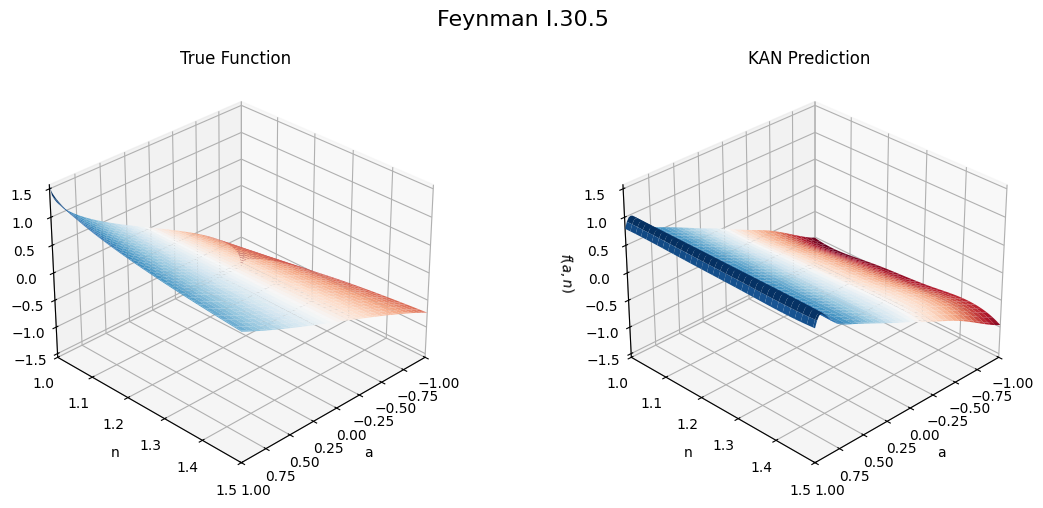

In [73]:
# Plot colormap
fig = plt.figure(figsize=(12,5))

# --- True function ---
ax1 = fig.add_subplot(121, projection='3d')
surf1 = ax1.plot_surface(X1_grid, X2_grid, Z_true, cmap='RdBu')

ax1.set_title("True Function")
ax1.set_xlabel("a")
ax1.set_ylabel("n")

# --- KAN prediction ---
ax2 = fig.add_subplot(122, projection='3d')
surf2 = ax2.plot_surface(X1_grid, X2_grid, Z_pred, cmap='RdBu')

ax2.set_title("KAN Prediction")
ax2.set_xlabel("a")
ax2.set_ylabel("n")
ax2.set_zlabel("$f(a, n)$")

# --- Make axes identical ---
zmin = min(Z_true.min(), Z_pred.min())
zmax = max(Z_true.max(), Z_pred.max())

for ax in [ax1, ax2]:
    ax.set_xlim(-1, 1)
    ax.set_ylim(1, 1.5)
    ax.set_zlim(zmin, zmax)
    ax.view_init(elev=30, azim=45)

plt.suptitle("Feynman I.30.5", fontsize=16)
plt.tight_layout()
plt.show()

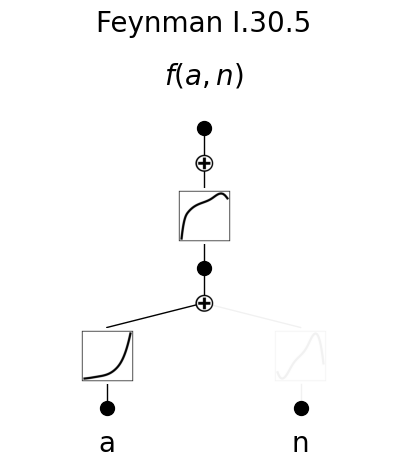

In [74]:
model_I_30_5.plot(in_vars=['a', 'n'], out_vars=['$f(a, n)$'], title="Feynman I.30.5")

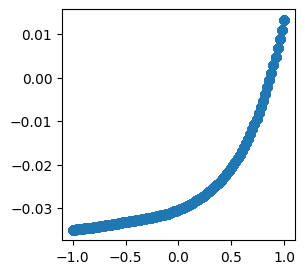

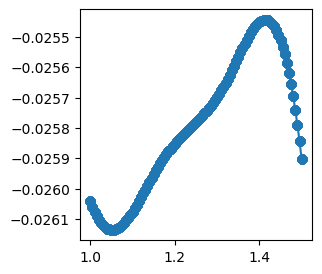

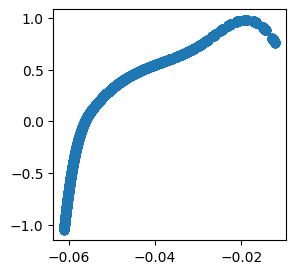

In [75]:
# label: "var_name + #th entry + _in/_out"
a0_in,a0_out = model_I_30_5.get_fun(0,0,0)
n0_in,n0_out = model_I_30_5.get_fun(0,1,0)
# label: "node + #th layer + _#th node + _in/_out"
node1_0_in, node1_0_out = model_I_30_5.get_fun(1,0,0)

In [76]:
os.makedirs("KAN_Feynman_activation_funcs/Feynman_I_30_5", exist_ok=True)
with open("KAN_Feynman_activation_funcs/Feynman_I_30_5/a0.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(a0_in, a0_out)))

with open("KAN_Feynman_activation_funcs/Feynman_I_30_5/n0.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(n0_in, n0_out)))

with open("KAN_Feynman_activation_funcs/Feynman_I_30_5/node1_0.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(node1_0_in, node1_0_out)))

**Feynman I.37.4**

In [77]:
f_I_37_4 = lambda x: 1 + x[:,[0]] + 2*torch.sqrt(x[:,[0]])*torch.cos(x[:,[1]])
dataset = create_dataset(f_I_37_4, n_var=2, device=device, train_num=100, test_num=100, ranges=[[0.1, 1], [0, 2*torch.pi]])

model_I_37_4 = KAN(width=[2,2,1], grid=3, k=3, seed=1, device=device)

checkpoint directory created: ./model
saving model version 0.0


In [78]:
model_I_37_4.fit(dataset, opt="LBFGS", steps=2000) #lr=1   # or opt="Adam"

| train_loss: 3.16e-02 | test_loss: 5.15e-02 | reg: 1.46e+01 | : 100%|█| 2000/2000 [00:17<00:00, 115


saving model version 0.1


{'train_loss': [array(0.3523403, dtype=float32),
  array(0.2470199, dtype=float32),
  array(0.22261076, dtype=float32),
  array(0.19417773, dtype=float32),
  array(0.1576685, dtype=float32),
  array(0.13203587, dtype=float32),
  array(0.11144297, dtype=float32),
  array(0.09984367, dtype=float32),
  array(0.09085507, dtype=float32),
  array(0.07856645, dtype=float32),
  array(0.08257613, dtype=float32),
  array(0.07751025, dtype=float32),
  array(0.07420163, dtype=float32),
  array(0.07110754, dtype=float32),
  array(0.06886728, dtype=float32),
  array(0.06770435, dtype=float32),
  array(0.06649895, dtype=float32),
  array(0.06528588, dtype=float32),
  array(0.06469043, dtype=float32),
  array(0.06418722, dtype=float32),
  array(0.06480213, dtype=float32),
  array(0.06447592, dtype=float32),
  array(0.06427546, dtype=float32),
  array(0.06394333, dtype=float32),
  array(0.06330402, dtype=float32),
  array(0.06209666, dtype=float32),
  array(0.06136779, dtype=float32),
  array(0.0603741

In [79]:
a_grid = np.linspace(0.1, 1, 101)
delta_grid = np.linspace(0, 2*torch.pi, 101)

X1_grid, X2_grid = np.meshgrid(a_grid, delta_grid)

# Convert grid to tensor input
grid_points = torch.tensor(
    np.stack([X1_grid.ravel(), X2_grid.ravel()], axis=1),
    dtype=torch.float32,
    device=device
)

Z_true = f_I_37_4(grid_points).numpy().reshape(X1_grid.shape)

# Get model predictions
with torch.no_grad():       # temporarily disables gradient tracking
    Z_pred = model_I_37_4(grid_points).numpy()
    # use the trained model to predict for the 101x101 grid points

# Reshape to grid
Z_pred = Z_pred.reshape(X1_grid.shape)

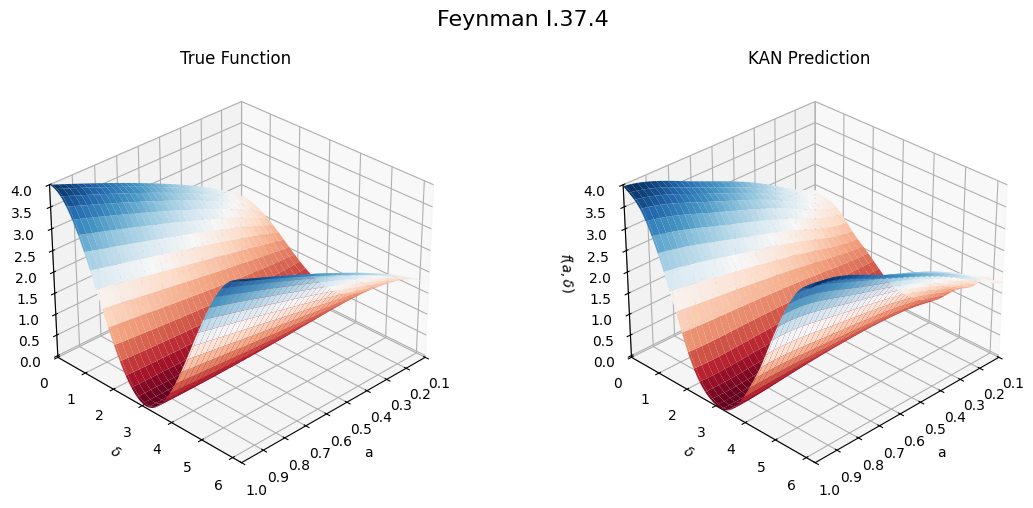

In [80]:
# Plot colormap
fig = plt.figure(figsize=(12,5))

# --- True function ---
ax1 = fig.add_subplot(121, projection='3d')
surf1 = ax1.plot_surface(X1_grid, X2_grid, Z_true, cmap='RdBu')

ax1.set_title("True Function")
ax1.set_xlabel("a")
ax1.set_ylabel("$\\delta$")

# --- KAN prediction ---
ax2 = fig.add_subplot(122, projection='3d')
surf2 = ax2.plot_surface(X1_grid, X2_grid, Z_pred, cmap='RdBu')

ax2.set_title("KAN Prediction")
ax2.set_xlabel("a")
ax2.set_ylabel("$\\delta$")
ax2.set_zlabel("$f(a, \\delta)$")

# --- Make axes identical ---
zmin = min(Z_true.min(), Z_pred.min())
zmax = max(Z_true.max(), Z_pred.max())

for ax in [ax1, ax2]:
    ax.set_xlim(0.1, 1)
    ax.set_ylim(0, 2*torch.pi)
    ax.set_zlim(zmin, zmax)
    ax.view_init(elev=30, azim=45)

plt.suptitle("Feynman I.37.4", fontsize=16)
plt.tight_layout()
plt.show()

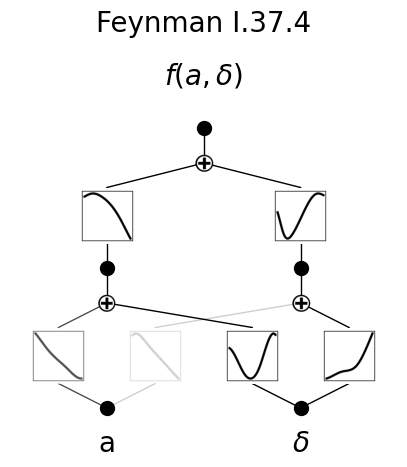

In [81]:
model_I_37_4.plot(in_vars=['a', '$\\delta$'], out_vars=['$f(a, \\delta)$'], title="Feynman I.37.4")

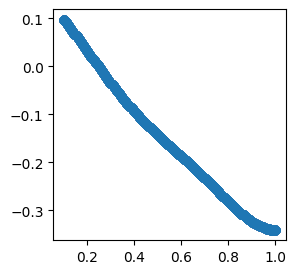

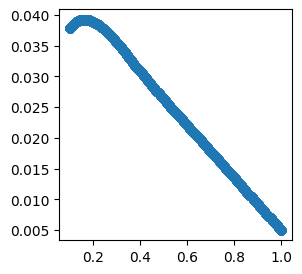

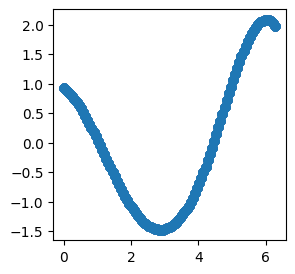

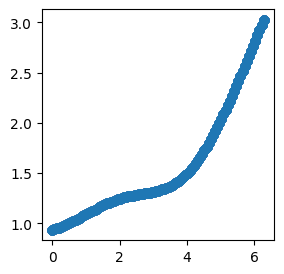

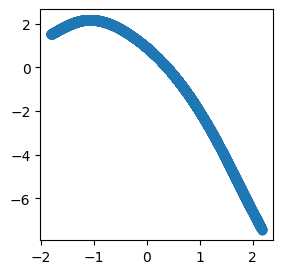

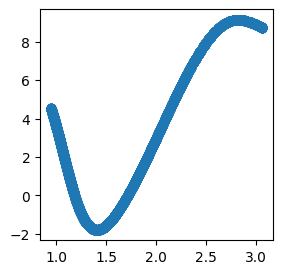

In [82]:
# label: "var_name + #th entry + _in/_out"
a0_in,a0_out = model_I_37_4.get_fun(0,0,0)
a1_in,a1_out = model_I_37_4.get_fun(0,0,1)
delta0_in,delta0_out = model_I_37_4.get_fun(0,1,0)
delta1_in,delta1_out = model_I_37_4.get_fun(0,1,1)
# label: "node + #th layer + _#th node + _in/_out"
node1_0_in, node1_0_out = model_I_37_4.get_fun(1,0,0)
node1_1_in,node1_1_out = model_I_37_4.get_fun(1,1,0)

In [83]:
os.makedirs("KAN_Feynman_activation_funcs/Feynman_I_37_4", exist_ok=True)
with open("KAN_Feynman_activation_funcs/Feynman_I_37_4/a0.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(a0_in, a0_out)))

with open("KAN_Feynman_activation_funcs/Feynman_I_37_4/a1.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(a1_in, a1_out)))

with open("KAN_Feynman_activation_funcs/Feynman_I_37_4/delta0.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(delta0_in, delta0_out)))

with open("KAN_Feynman_activation_funcs/Feynman_I_37_4/delta1.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(delta1_in, delta1_out)))

with open("KAN_Feynman_activation_funcs/Feynman_I_37_4/node1_0.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(node1_0_in, node1_0_out)))

with open("KAN_Feynman_activation_funcs/Feynman_I_37_4/node1_1.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(node1_1_in, node1_1_out)))


**Feynman I.40.1**

In [100]:
f_I_40_1 = lambda x: x[:,[0]] * torch.exp(-x[:,[1]])
dataset = create_dataset(f_I_40_1, n_var=2, device=device, train_num=100, test_num=100, ranges=[[0, 1], [-1, 1]])

model_I_40_1 = KAN(width=[2,2,1], grid=3, k=3, seed=1, device=device)

checkpoint directory created: ./model
saving model version 0.0


In [101]:
model_I_40_1.fit(dataset, opt="LBFGS", steps=2000) #lr=1   # or opt="Adam"

| train_loss: 1.47e-03 | test_loss: 5.65e-03 | reg: 7.71e+00 | : 100%|█| 2000/2000 [00:17<00:00, 111


saving model version 0.1


{'train_loss': [array(0.04250205, dtype=float32),
  array(0.01946516, dtype=float32),
  array(0.01494693, dtype=float32),
  array(0.01327339, dtype=float32),
  array(0.01150451, dtype=float32),
  array(0.00869821, dtype=float32),
  array(0.0066589, dtype=float32),
  array(0.00552623, dtype=float32),
  array(0.0048245, dtype=float32),
  array(0.00433742, dtype=float32),
  array(0.00365174, dtype=float32),
  array(0.00338525, dtype=float32),
  array(0.00319645, dtype=float32),
  array(0.00296539, dtype=float32),
  array(0.00289257, dtype=float32),
  array(0.00270623, dtype=float32),
  array(0.0025672, dtype=float32),
  array(0.0024284, dtype=float32),
  array(0.0023404, dtype=float32),
  array(0.00224307, dtype=float32),
  array(0.00211763, dtype=float32),
  array(0.00200521, dtype=float32),
  array(0.00189644, dtype=float32),
  array(0.00181, dtype=float32),
  array(0.00176491, dtype=float32),
  array(0.00175083, dtype=float32),
  array(0.00173147, dtype=float32),
  array(0.00169294, dt

In [102]:
n_grid = np.linspace(0, 1, 101)
a_grid = np.linspace(-1, 1, 101)

X1_grid, X2_grid = np.meshgrid(n_grid, a_grid)

# Convert grid to tensor input
grid_points = torch.tensor(
    np.stack([X1_grid.ravel(), X2_grid.ravel()], axis=1),
    dtype=torch.float32,
    device=device
)

Z_true = f_I_40_1(grid_points).numpy().reshape(X1_grid.shape)

# Get model predictions
with torch.no_grad():       # temporarily disables gradient tracking
    Z_pred = model_I_40_1(grid_points).numpy()
    # use the trained model to predict for the 101x101 grid points

# Reshape to grid
Z_pred = Z_pred.reshape(X1_grid.shape)

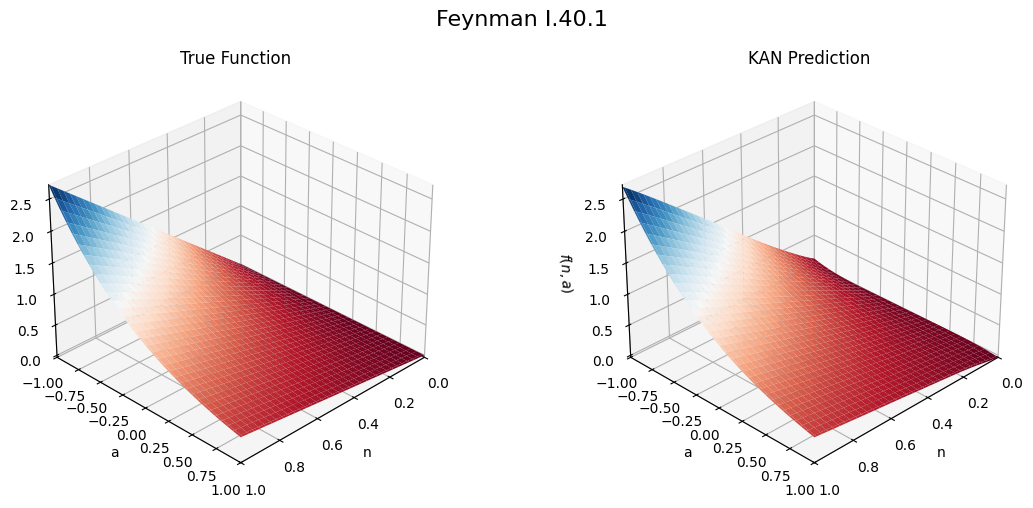

In [103]:
# Plot colormap
fig = plt.figure(figsize=(12,5))

# --- True function ---
ax1 = fig.add_subplot(121, projection='3d')
surf1 = ax1.plot_surface(X1_grid, X2_grid, Z_true, cmap='RdBu')

ax1.set_title("True Function")
ax1.set_xlabel("n")
ax1.set_ylabel("a")

# --- KAN prediction ---
ax2 = fig.add_subplot(122, projection='3d')
surf2 = ax2.plot_surface(X1_grid, X2_grid, Z_pred, cmap='RdBu')

ax2.set_title("KAN Prediction")
ax2.set_xlabel("n")
ax2.set_ylabel("a")
ax2.set_zlabel("$f(n, a)$")

# --- Make axes identical ---
zmin = min(Z_true.min(), Z_pred.min())
zmax = max(Z_true.max(), Z_pred.max())

for ax in [ax1, ax2]:
    ax.set_xlim(0, 1)
    ax.set_ylim(-1, 1)
    ax.set_zlim(zmin, zmax)
    ax.view_init(elev=30, azim=45)

plt.suptitle("Feynman I.40.1", fontsize=16)
plt.tight_layout()
plt.show()

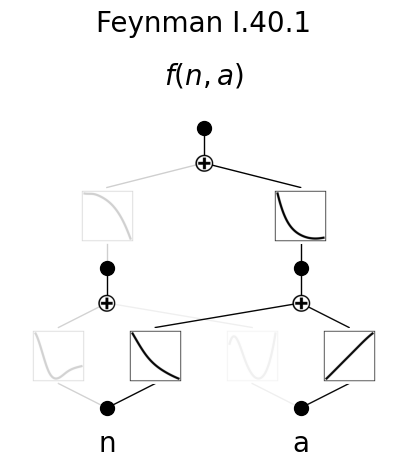

In [104]:
model_I_40_1.plot(in_vars=['n', 'a'], out_vars=['$f(n, a)$'], title="Feynman I.40.1")

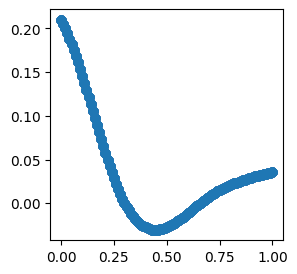

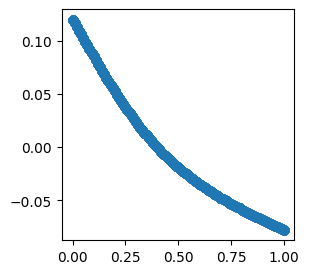

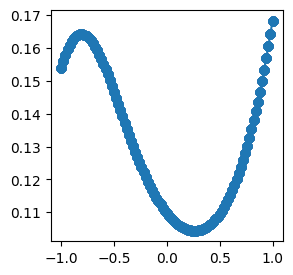

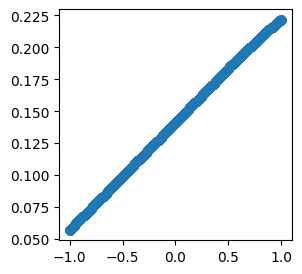

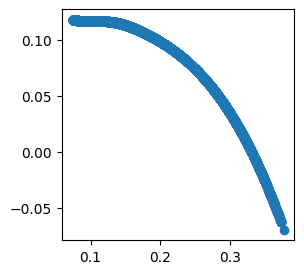

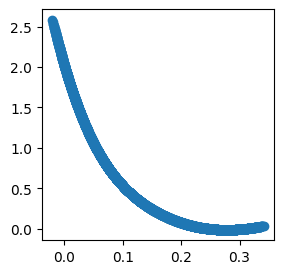

In [105]:
# label: "var_name + #th entry + _in/_out"
n0_in,n0_out = model_I_40_1.get_fun(0,0,0)
n1_in,n1_out = model_I_40_1.get_fun(0,0,1)
a0_in,a0_out = model_I_40_1.get_fun(0,1,0)
a1_in,a1_out = model_I_40_1.get_fun(0,1,1)
# label: "node + #th layer + _#th node + _in/_out"
node1_0_in, node1_0_out = model_I_40_1.get_fun(1,0,0)
node1_1_in,node1_1_out = model_I_40_1.get_fun(1,1,0)

In [106]:
os.makedirs("KAN_Feynman_activation_funcs/Feynman_I_40_1", exist_ok=True)
with open("KAN_Feynman_activation_funcs/Feynman_I_40_1/n0.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(n0_in, n0_out)))

with open("KAN_Feynman_activation_funcs/Feynman_I_40_1/n1.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(n1_in, n1_out)))

with open("KAN_Feynman_activation_funcs/Feynman_I_40_1/a0.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(a0_in, a0_out)))

with open("KAN_Feynman_activation_funcs/Feynman_I_40_1/a1.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(a1_in, a1_out)))

with open("KAN_Feynman_activation_funcs/Feynman_I_40_1/node1_0.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(node1_0_in, node1_0_out)))

with open("KAN_Feynman_activation_funcs/Feynman_I_40_1/node1_1.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(node1_1_in, node1_1_out)))


**Feynman I.44.4**

In [107]:
f_I_44_4 = lambda x: x[:,[0]] * torch.log(x[:,[1]])
dataset = create_dataset(f_I_44_4, n_var=2, device=device, train_num=100, test_num=100, ranges=[[0, 1], [0.25, 4]])

model_I_44_4 = KAN(width=[2,2,1], grid=3, k=3, seed=1, device=device)

checkpoint directory created: ./model
saving model version 0.0


In [108]:
model_I_44_4.fit(dataset, opt="LBFGS", steps=2000) #lr=1   # or opt="Adam"

| train_loss: 1.13e-03 | test_loss: 4.39e-03 | reg: 1.03e+01 | : 100%|█| 2000/2000 [00:14<00:00, 139


saving model version 0.1


{'train_loss': [array(0.09620537, dtype=float32),
  array(0.03718122, dtype=float32),
  array(0.02274213, dtype=float32),
  array(0.01563859, dtype=float32),
  array(0.01279744, dtype=float32),
  array(0.01118273, dtype=float32),
  array(0.00941463, dtype=float32),
  array(0.00870997, dtype=float32),
  array(0.00802356, dtype=float32),
  array(0.00754626, dtype=float32),
  array(0.00773878, dtype=float32),
  array(0.0067778, dtype=float32),
  array(0.00608239, dtype=float32),
  array(0.00559182, dtype=float32),
  array(0.0050461, dtype=float32),
  array(0.00470025, dtype=float32),
  array(0.00450198, dtype=float32),
  array(0.00395619, dtype=float32),
  array(0.00385819, dtype=float32),
  array(0.00382371, dtype=float32),
  array(0.00379585, dtype=float32),
  array(0.00327285, dtype=float32),
  array(0.00292387, dtype=float32),
  array(0.00281463, dtype=float32),
  array(0.0026446, dtype=float32),
  array(0.00253502, dtype=float32),
  array(0.00241437, dtype=float32),
  array(0.0023572

In [109]:
n_grid = np.linspace(0, 1, 101)
a_grid = np.linspace(0.25, 4, 101)

X1_grid, X2_grid = np.meshgrid(n_grid, a_grid)

# Convert grid to tensor input
grid_points = torch.tensor(
    np.stack([X1_grid.ravel(), X2_grid.ravel()], axis=1),
    dtype=torch.float32,
    device=device
)

Z_true = f_I_44_4(grid_points).numpy().reshape(X1_grid.shape)

# Get model predictions
with torch.no_grad():       # temporarily disables gradient tracking
    Z_pred = model_I_44_4(grid_points).numpy()
    # use the trained model to predict for the 101x101 grid points

# Reshape to grid
Z_pred = Z_pred.reshape(X1_grid.shape)

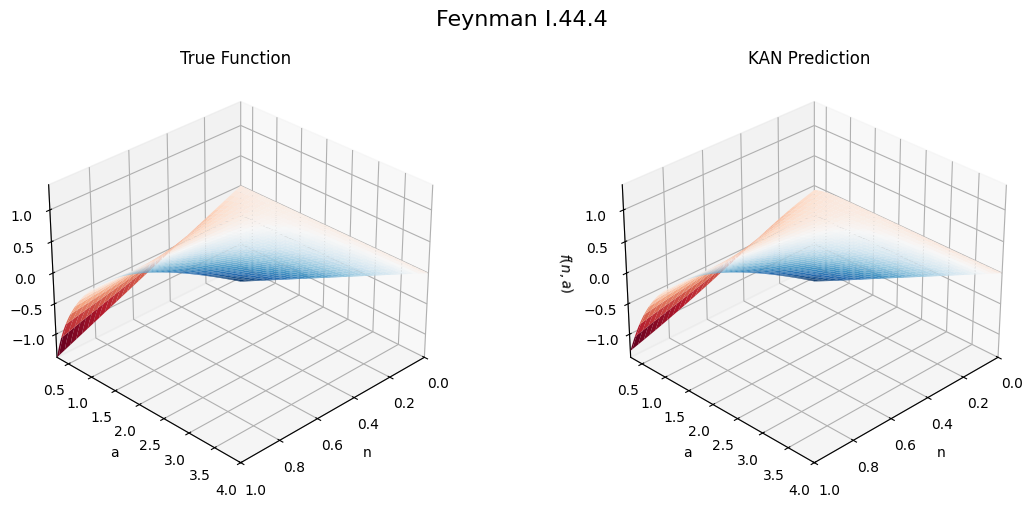

In [110]:
# Plot colormap
fig = plt.figure(figsize=(12,5))

# --- True function ---
ax1 = fig.add_subplot(121, projection='3d')
surf1 = ax1.plot_surface(X1_grid, X2_grid, Z_true, cmap='RdBu')

ax1.set_title("True Function")
ax1.set_xlabel("n")
ax1.set_ylabel("a")

# --- KAN prediction ---
ax2 = fig.add_subplot(122, projection='3d')
surf2 = ax2.plot_surface(X1_grid, X2_grid, Z_pred, cmap='RdBu')

ax2.set_title("KAN Prediction")
ax2.set_xlabel("n")
ax2.set_ylabel("a")
ax2.set_zlabel("$f(n, a)$")

# --- Make axes identical ---
zmin = min(Z_true.min(), Z_pred.min())
zmax = max(Z_true.max(), Z_pred.max())

for ax in [ax1, ax2]:
    ax.set_xlim(0, 1)
    ax.set_ylim(0.25, 4)
    ax.set_zlim(zmin, zmax)
    ax.view_init(elev=30, azim=45)

plt.suptitle("Feynman I.44.4", fontsize=16)
plt.tight_layout()
plt.show()

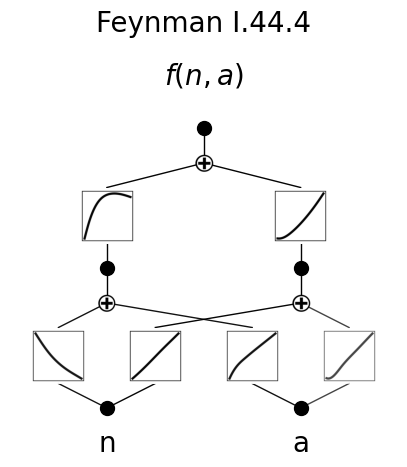

In [111]:
model_I_44_4.plot(in_vars=['n', 'a'], out_vars=['$f(n, a)$'], title="Feynman I.44.4")

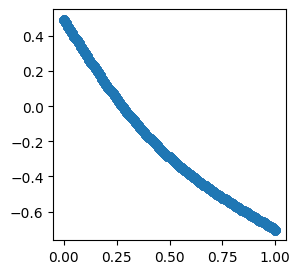

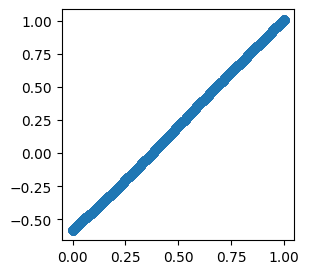

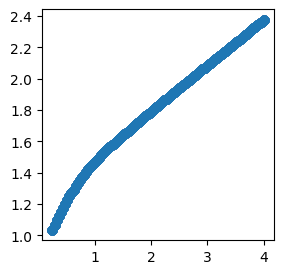

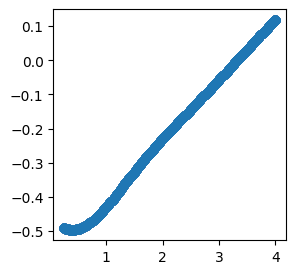

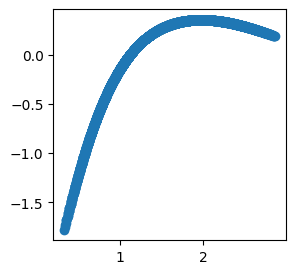

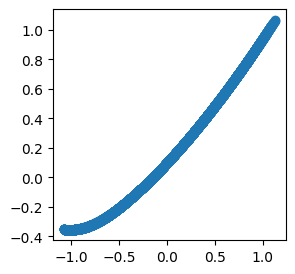

In [112]:
# label: "var_name + #th entry + _in/_out"
n0_in,n0_out = model_I_44_4.get_fun(0,0,0)
n1_in,n1_out = model_I_44_4.get_fun(0,0,1)
a0_in,a0_out = model_I_44_4.get_fun(0,1,0)
a1_in,a1_out = model_I_44_4.get_fun(0,1,1)
# label: "node + #th layer + _#th node + _in/_out"
node1_0_in, node1_0_out = model_I_44_4.get_fun(1,0,0)
node1_1_in,node1_1_out = model_I_44_4.get_fun(1,1,0)

In [113]:
os.makedirs("KAN_Feynman_activation_funcs/Feynman_I_44_4", exist_ok=True)
with open("KAN_Feynman_activation_funcs/Feynman_I_44_4/n0.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(n0_in, n0_out)))

with open("KAN_Feynman_activation_funcs/Feynman_I_44_4/n1.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(n1_in, n1_out)))

with open("KAN_Feynman_activation_funcs/Feynman_I_44_4/a0.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(a0_in, a0_out)))

with open("KAN_Feynman_activation_funcs/Feynman_I_44_4/a1.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(a1_in, a1_out)))

with open("KAN_Feynman_activation_funcs/Feynman_I_44_4/node1_0.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(node1_0_in, node1_0_out)))

with open("KAN_Feynman_activation_funcs/Feynman_I_44_4/node1_1.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(node1_1_in, node1_1_out)))


**Feynman I.50.26**

In [114]:
f_I_50_26 = lambda x: torch.cos(x[:,[0]]) + x[:,[1]] * (torch.cos(x[:,[0]]))**2
dataset = create_dataset(f_I_50_26, n_var=2, device=device, train_num=100, test_num=100, ranges=[[0, 2*torch.pi], [0, 1]])

model_I_50_26 = KAN(width=[2,3,1], grid=3, k=3, seed=1, device=device)

checkpoint directory created: ./model
saving model version 0.0


In [115]:
model_I_50_26.fit(dataset, opt="LBFGS", steps=2000) #lr=1   # or opt="Adam"

| train_loss: 4.54e-03 | test_loss: 1.53e-02 | reg: 1.30e+01 | : 100%|█| 2000/2000 [00:20<00:00, 97.


saving model version 0.1


{'train_loss': [array(0.12289296, dtype=float32),
  array(0.0746196, dtype=float32),
  array(0.0642913, dtype=float32),
  array(0.05099287, dtype=float32),
  array(0.04066682, dtype=float32),
  array(0.04247588, dtype=float32),
  array(0.03991427, dtype=float32),
  array(0.03757072, dtype=float32),
  array(0.03103312, dtype=float32),
  array(0.02522258, dtype=float32),
  array(0.03060759, dtype=float32),
  array(0.02686116, dtype=float32),
  array(0.02466368, dtype=float32),
  array(0.02259126, dtype=float32),
  array(0.02157238, dtype=float32),
  array(0.0231959, dtype=float32),
  array(0.02148184, dtype=float32),
  array(0.02033768, dtype=float32),
  array(0.01969685, dtype=float32),
  array(0.01803559, dtype=float32),
  array(0.02152623, dtype=float32),
  array(0.01881159, dtype=float32),
  array(0.01610962, dtype=float32),
  array(0.01460465, dtype=float32),
  array(0.01374541, dtype=float32),
  array(0.01394379, dtype=float32),
  array(0.01351931, dtype=float32),
  array(0.0131505

In [116]:
a_grid = np.linspace(0, 2*torch.pi, 101)
alpha_grid = np.linspace(0, 1, 101)

X1_grid, X2_grid = np.meshgrid(a_grid, alpha_grid)

# Convert grid to tensor input
grid_points = torch.tensor(
    np.stack([X1_grid.ravel(), X2_grid.ravel()], axis=1),
    dtype=torch.float32,
    device=device
)

Z_true = f_I_50_26(grid_points).numpy().reshape(X1_grid.shape)

# Get model predictions
with torch.no_grad():       # temporarily disables gradient tracking
    Z_pred = model_I_50_26(grid_points).numpy()
    # use the trained model to predict for the 101x101 grid points

# Reshape to grid
Z_pred = Z_pred.reshape(X1_grid.shape)

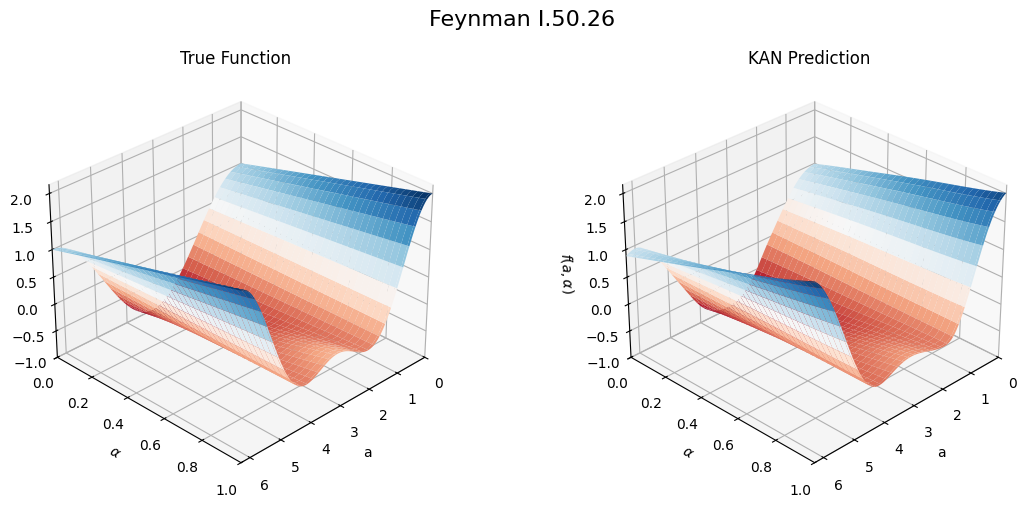

In [117]:
# Plot colormap
fig = plt.figure(figsize=(12,5))

# --- True function ---
ax1 = fig.add_subplot(121, projection='3d')
surf1 = ax1.plot_surface(X1_grid, X2_grid, Z_true, cmap='RdBu')

ax1.set_title("True Function")
ax1.set_xlabel("a")
ax1.set_ylabel("$\\alpha$")

# --- KAN prediction ---
ax2 = fig.add_subplot(122, projection='3d')
surf2 = ax2.plot_surface(X1_grid, X2_grid, Z_pred, cmap='RdBu')

ax2.set_title("KAN Prediction")
ax2.set_xlabel("a")
ax2.set_ylabel("$\\alpha$")
ax2.set_zlabel("$f(a, \\alpha)$")

# --- Make axes identical ---
zmin = min(Z_true.min(), Z_pred.min())
zmax = max(Z_true.max(), Z_pred.max())

for ax in [ax1, ax2]:
    ax.set_xlim(0, 2*torch.pi)
    ax.set_ylim(0, 1)
    ax.set_zlim(zmin, zmax)
    ax.view_init(elev=30, azim=45)

plt.suptitle("Feynman I.50.26", fontsize=16)
plt.tight_layout()
plt.show()

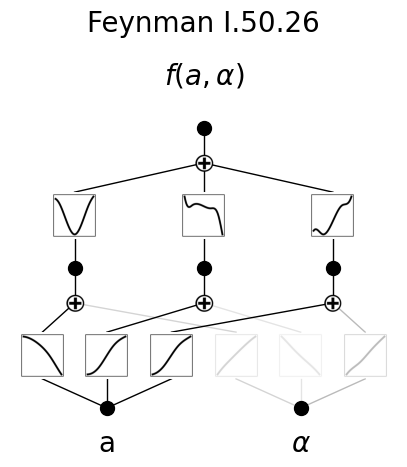

In [118]:
model_I_50_26.plot(in_vars=['a', '$\\alpha$'], out_vars=['$f(a, \\alpha)$'], title="Feynman I.50.26")

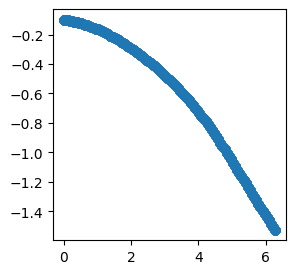

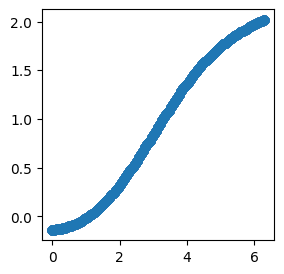

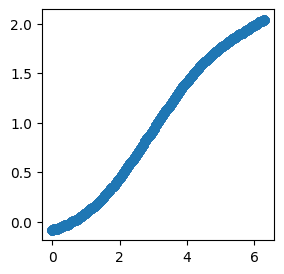

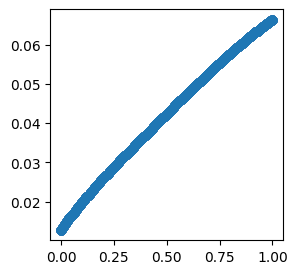

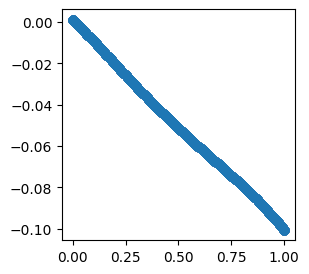

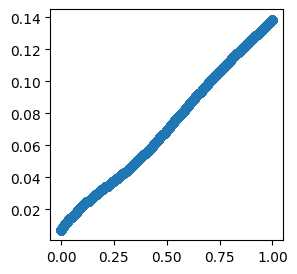

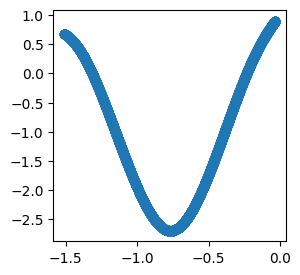

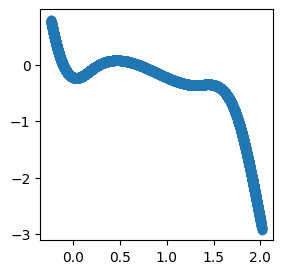

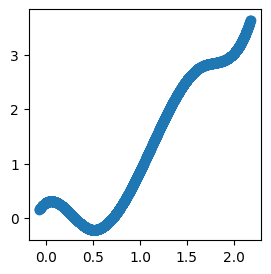

In [119]:
# label: "var_name + #th entry + _in/_out"
a0_in,a0_out = model_I_50_26.get_fun(0,0,0)
a1_in,a1_out = model_I_50_26.get_fun(0,0,1)
a2_in,a2_out = model_I_50_26.get_fun(0,0,2)
alpha0_in,alpha0_out = model_I_50_26.get_fun(0,1,0)
alpha1_in,alpha1_out = model_I_50_26.get_fun(0,1,1)
alpha2_in,alpha2_out = model_I_50_26.get_fun(0,1,2)
# label: "node + #th layer + _#th node + _in/_out"
node1_0_in, node1_0_out = model_I_50_26.get_fun(1,0,0)
node1_1_in,node1_1_out = model_I_50_26.get_fun(1,1,0)
node1_2_in,node1_2_out = model_I_50_26.get_fun(1,2,0)

In [120]:
os.makedirs("KAN_Feynman_activation_funcs/Feynman_I_50_26", exist_ok=True)
with open("KAN_Feynman_activation_funcs/Feynman_I_50_26/a0.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(a0_in, a0_out)))

with open("KAN_Feynman_activation_funcs/Feynman_I_50_26/a1.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(a1_in, a1_out)))

with open("KAN_Feynman_activation_funcs/Feynman_I_50_26/a2.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(a2_in, a2_out)))

with open("KAN_Feynman_activation_funcs/Feynman_I_50_26/alpha0.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(alpha0_in, alpha0_out)))

with open("KAN_Feynman_activation_funcs/Feynman_I_50_26/alpha1.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(alpha1_in, alpha1_out)))

with open("KAN_Feynman_activation_funcs/Feynman_I_50_26/alpha2.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(alpha2_in, alpha2_out)))

with open("KAN_Feynman_activation_funcs/Feynman_I_50_26/node1_0.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(node1_0_in, node1_0_out)))

with open("KAN_Feynman_activation_funcs/Feynman_I_50_26/node1_1.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(node1_1_in, node1_1_out)))

with open("KAN_Feynman_activation_funcs/Feynman_I_50_26/node1_2.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(node1_2_in, node1_2_out)))

**Feynman II.2.42**

In [121]:
f_II_2_42 = lambda x: (x[:,[0]] -1) * x[:,[1]]
dataset = create_dataset(f_II_2_42, n_var=2, device=device, train_num=100, test_num=100, ranges=[[0, 1], [0, 2]])

model_II_2_42 = KAN(width=[2,2,1], grid=3, k=3, seed=1, device=device)

checkpoint directory created: ./model
saving model version 0.0


In [122]:
model_II_2_42.fit(dataset, opt="LBFGS", steps=2000) #lr=1   # or opt="Adam"

| train_loss: 3.24e-04 | test_loss: 5.11e-04 | reg: 9.49e+00 | : 100%|█| 2000/2000 [00:14<00:00, 135


saving model version 0.1


{'train_loss': [array(0.0186092, dtype=float32),
  array(0.00828677, dtype=float32),
  array(0.00614892, dtype=float32),
  array(0.00486695, dtype=float32),
  array(0.00406776, dtype=float32),
  array(0.00377795, dtype=float32),
  array(0.003494, dtype=float32),
  array(0.00290153, dtype=float32),
  array(0.00251582, dtype=float32),
  array(0.00231126, dtype=float32),
  array(0.00214063, dtype=float32),
  array(0.00189959, dtype=float32),
  array(0.00152961, dtype=float32),
  array(0.00137347, dtype=float32),
  array(0.00118366, dtype=float32),
  array(0.00113319, dtype=float32),
  array(0.00107179, dtype=float32),
  array(0.00099459, dtype=float32),
  array(0.0009537, dtype=float32),
  array(0.0008797, dtype=float32),
  array(0.00080326, dtype=float32),
  array(0.00076279, dtype=float32),
  array(0.00068219, dtype=float32),
  array(0.00066433, dtype=float32),
  array(0.00060895, dtype=float32),
  array(0.00055382, dtype=float32),
  array(0.00050817, dtype=float32),
  array(0.00047513,

In [123]:
a_grid = np.linspace(0, 1, 101)
b_grid = np.linspace(0, 2, 101)

X1_grid, X2_grid = np.meshgrid(a_grid, b_grid)

# Convert grid to tensor input
grid_points = torch.tensor(
    np.stack([X1_grid.ravel(), X2_grid.ravel()], axis=1),
    dtype=torch.float32,
    device=device
)

Z_true = f_II_2_42(grid_points).numpy().reshape(X1_grid.shape)

# Get model predictions
with torch.no_grad():       # temporarily disables gradient tracking
    Z_pred = model_II_2_42(grid_points).numpy()
    # use the trained model to predict for the 101x101 grid points

# Reshape to grid
Z_pred = Z_pred.reshape(X1_grid.shape)

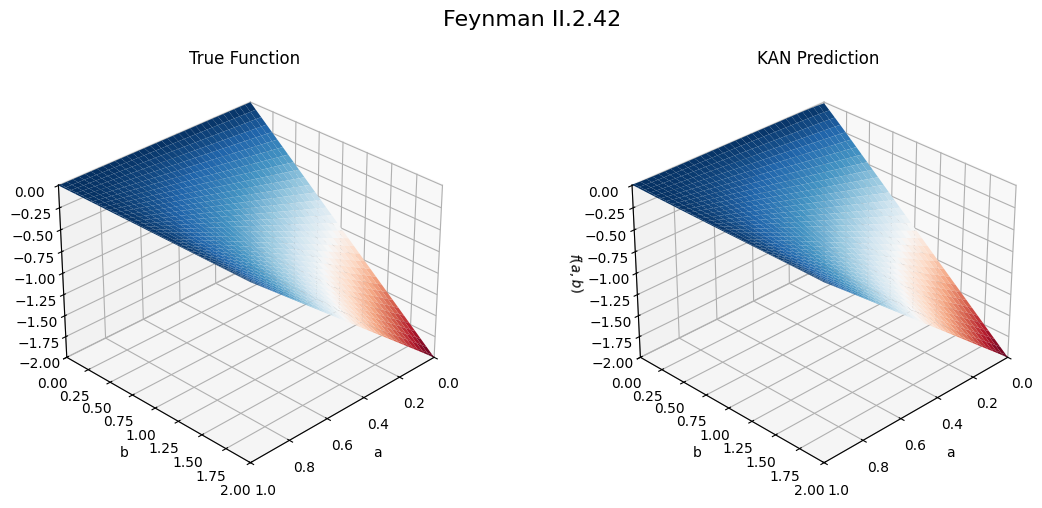

In [124]:
# Plot colormap
fig = plt.figure(figsize=(12,5))

# --- True function ---
ax1 = fig.add_subplot(121, projection='3d')
surf1 = ax1.plot_surface(X1_grid, X2_grid, Z_true, cmap='RdBu')

ax1.set_title("True Function")
ax1.set_xlabel("a")
ax1.set_ylabel("b")

# --- KAN prediction ---
ax2 = fig.add_subplot(122, projection='3d')
surf2 = ax2.plot_surface(X1_grid, X2_grid, Z_pred, cmap='RdBu')

ax2.set_title("KAN Prediction")
ax2.set_xlabel("a")
ax2.set_ylabel("b")
ax2.set_zlabel("$f(a, b)$")

# --- Make axes identical ---
zmin = min(Z_true.min(), Z_pred.min())
zmax = max(Z_true.max(), Z_pred.max())

for ax in [ax1, ax2]:
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 2)
    ax.set_zlim(zmin, zmax)
    ax.view_init(elev=30, azim=45)

plt.suptitle("Feynman II.2.42", fontsize=16)
plt.tight_layout()
plt.show()

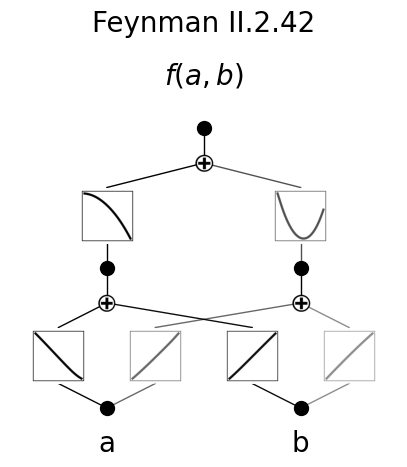

In [125]:
model_II_2_42.plot(in_vars=['a', 'b'], out_vars=['$f(a, b)$'], title="Feynman II.2.42")

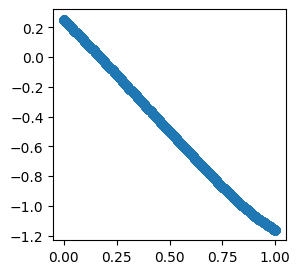

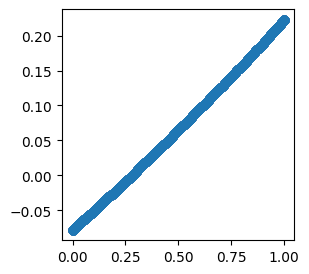

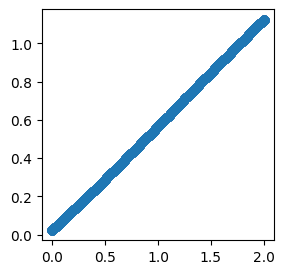

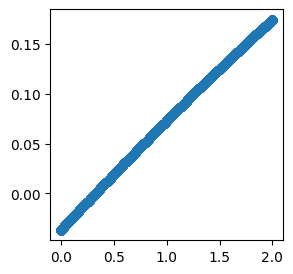

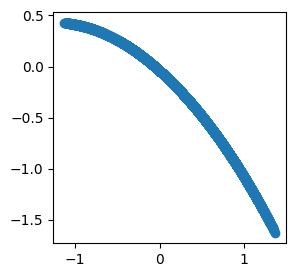

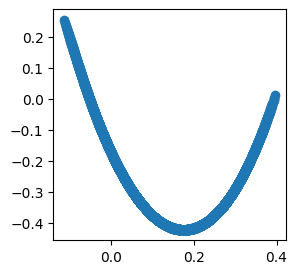

In [126]:
# label: "var_name + #th entry + _in/_out"
a0_in,a0_out = model_II_2_42.get_fun(0,0,0)
a1_in,a1_out = model_II_2_42.get_fun(0,0,1)
b0_in,b0_out = model_II_2_42.get_fun(0,1,0)
b1_in,b1_out = model_II_2_42.get_fun(0,1,1)
# label: "node + #th layer + _#th node + _in/_out"
node1_0_in, node1_0_out = model_II_2_42.get_fun(1,0,0)
node1_1_in,node1_1_out = model_II_2_42.get_fun(1,1,0)

In [127]:
os.makedirs("KAN_Feynman_activation_funcs/Feynman_II_2_42", exist_ok=True)
with open("KAN_Feynman_activation_funcs/Feynman_II_2_42/a0.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(a0_in, a0_out)))

with open("KAN_Feynman_activation_funcs/Feynman_II_2_42/a1.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(a1_in, a1_out)))

with open("KAN_Feynman_activation_funcs/Feynman_II_2_42/b0.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(b0_in, b0_out)))

with open("KAN_Feynman_activation_funcs/Feynman_II_2_42/b1.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(b1_in, b1_out)))

with open("KAN_Feynman_activation_funcs/Feynman_II_2_42/node1_0.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(node1_0_in, node1_0_out)))

with open("KAN_Feynman_activation_funcs/Feynman_II_2_42/node1_1.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(node1_1_in, node1_1_out)))

**Feynman II.11.27**

In [128]:
f_II_11_27 = lambda x: (x[:,[0]] * x[:,[1]])/(1 - (x[:,[0]] * x[:,[1]])/3)
dataset = create_dataset(f_II_11_27, n_var=2, device=device, train_num=100, test_num=100, ranges=[[0, 1], [0, 2]])

model_II_11_27 = KAN(width=[2,1,1], grid=3, k=3, seed=1, device=device)

checkpoint directory created: ./model
saving model version 0.0


In [129]:
model_II_11_27.fit(dataset, opt="LBFGS", steps=2000) #lr=1   # or opt="Adam"

| train_loss: 7.93e-03 | test_loss: 3.86e-02 | reg: 7.58e+00 | : 100%|█| 2000/2000 [00:15<00:00, 128


saving model version 0.1


{'train_loss': [array(0.1570497, dtype=float32),
  array(0.0807834, dtype=float32),
  array(0.07399117, dtype=float32),
  array(0.05831122, dtype=float32),
  array(0.05149593, dtype=float32),
  array(0.04773939, dtype=float32),
  array(0.04671888, dtype=float32),
  array(0.04598564, dtype=float32),
  array(0.0398441, dtype=float32),
  array(0.03742495, dtype=float32),
  array(0.04018088, dtype=float32),
  array(0.03916442, dtype=float32),
  array(0.03874256, dtype=float32),
  array(0.03819093, dtype=float32),
  array(0.03658742, dtype=float32),
  array(0.03531568, dtype=float32),
  array(0.03452324, dtype=float32),
  array(0.03402805, dtype=float32),
  array(0.03391151, dtype=float32),
  array(0.03379047, dtype=float32),
  array(0.03380528, dtype=float32),
  array(0.03362847, dtype=float32),
  array(0.03333599, dtype=float32),
  array(0.03264461, dtype=float32),
  array(0.0320504, dtype=float32),
  array(0.02884221, dtype=float32),
  array(0.0279677, dtype=float32),
  array(0.02752655,

In [130]:
n_grid = np.linspace(0, 1, 101)
alpha_grid = np.linspace(0, 2, 101)

X1_grid, X2_grid = np.meshgrid(n_grid, alpha_grid)

# Convert grid to tensor input
grid_points = torch.tensor(
    np.stack([X1_grid.ravel(), X2_grid.ravel()], axis=1),
    dtype=torch.float32,
    device=device
)

Z_true = f_II_11_27(grid_points).numpy().reshape(X1_grid.shape)

# Get model predictions
with torch.no_grad():       # temporarily disables gradient tracking
    Z_pred = model_II_11_27(grid_points).numpy()
    # use the trained model to predict for the 101x101 grid points

# Reshape to grid
Z_pred = Z_pred.reshape(X1_grid.shape)

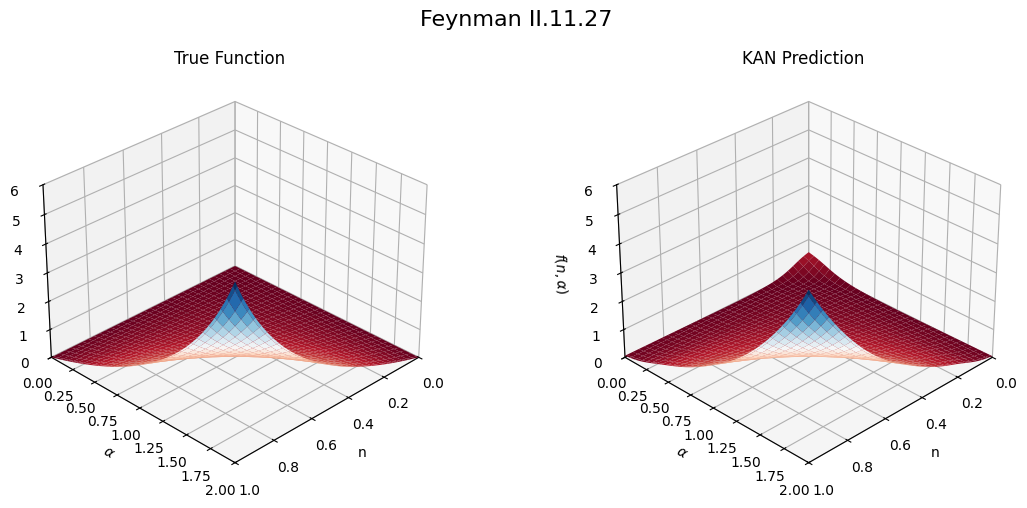

In [131]:
# Plot colormap
fig = plt.figure(figsize=(12,5))

# --- True function ---
ax1 = fig.add_subplot(121, projection='3d')
surf1 = ax1.plot_surface(X1_grid, X2_grid, Z_true, cmap='RdBu')

ax1.set_title("True Function")
ax1.set_xlabel("n")
ax1.set_ylabel("$\\alpha$")

# --- KAN prediction ---
ax2 = fig.add_subplot(122, projection='3d')
surf2 = ax2.plot_surface(X1_grid, X2_grid, Z_pred, cmap='RdBu')

ax2.set_title("KAN Prediction")
ax2.set_xlabel("n")
ax2.set_ylabel("$\\alpha$")
ax2.set_zlabel("$f(n, \\alpha)$")

# --- Make axes identical ---
zmin = min(Z_true.min(), Z_pred.min())
zmax = max(Z_true.max(), Z_pred.max())

for ax in [ax1, ax2]:
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 2)
    ax.set_zlim(zmin, zmax)
    ax.view_init(elev=30, azim=45)

plt.suptitle("Feynman II.11.27", fontsize=16)
plt.tight_layout()
plt.show()

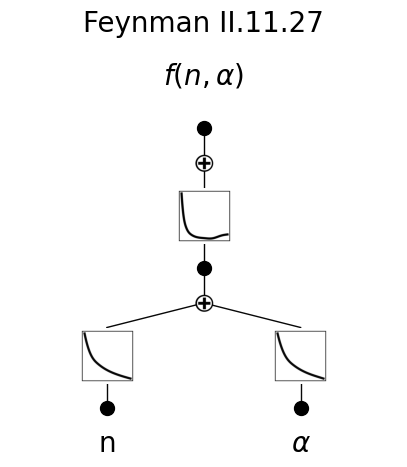

In [132]:
model_II_11_27.plot(in_vars=['n', '$\\alpha$'], out_vars=['$f(n, \\alpha)$'], title="Feynman II.11.27")

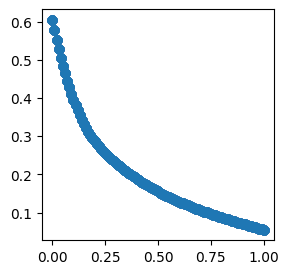

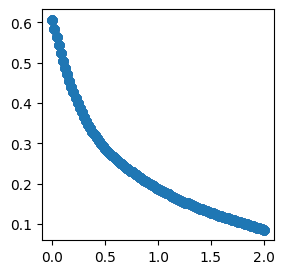

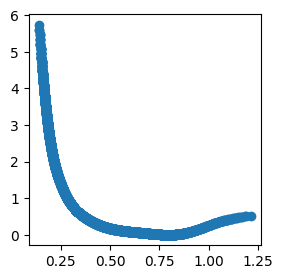

In [134]:
# label: "var_name + #th entry + _in/_out"
n0_in,n0_out = model_II_11_27.get_fun(0,0,0)
alpha0_in,alpha0_out = model_II_11_27.get_fun(0,1,0)
# label: "node + #th layer + _#th node + _in/_out"
node1_0_in, node1_0_out = model_II_11_27.get_fun(1,0,0)

In [135]:
os.makedirs("KAN_Feynman_activation_funcs/Feynman_II_11_27", exist_ok=True)
with open("KAN_Feynman_activation_funcs/Feynman_II_11_27/n0.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(n0_in, n0_out)))

with open("KAN_Feynman_activation_funcs/Feynman_II_11_27/alpha0.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(alpha0_in, alpha0_out)))

with open("KAN_Feynman_activation_funcs/Feynman_II_11_27/node1_0.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(node1_0_in, node1_0_out)))

**Feynman II.35.18**

In [136]:
f_II_35_18 = lambda x: x[:,[0]]/(torch.exp(x[:,[1]]) + torch.exp(-x[:,[1]]))
dataset = create_dataset(f_II_35_18, n_var=2, device=device, train_num=100, test_num=100, ranges=[[0, 1], [0, 4]])

model_II_35_18 = KAN(width=[2,1,1], grid=3, k=3, seed=1, device=device)

checkpoint directory created: ./model
saving model version 0.0


In [137]:
model_II_35_18.fit(dataset, opt="LBFGS", steps=2000) #lr=1   # or opt="Adam"

| train_loss: 7.05e-04 | test_loss: 7.76e-04 | reg: 5.65e+00 | : 100%|█| 2000/2000 [00:13<00:00, 152


saving model version 0.1


{'train_loss': [array(0.00700287, dtype=float32),
  array(0.00487104, dtype=float32),
  array(0.00424219, dtype=float32),
  array(0.00400061, dtype=float32),
  array(0.00378766, dtype=float32),
  array(0.00344836, dtype=float32),
  array(0.00316082, dtype=float32),
  array(0.00278885, dtype=float32),
  array(0.00229501, dtype=float32),
  array(0.00155051, dtype=float32),
  array(0.00127729, dtype=float32),
  array(0.00118605, dtype=float32),
  array(0.00111004, dtype=float32),
  array(0.00102807, dtype=float32),
  array(0.00096301, dtype=float32),
  array(0.00088608, dtype=float32),
  array(0.00086647, dtype=float32),
  array(0.00084262, dtype=float32),
  array(0.00082291, dtype=float32),
  array(0.00080371, dtype=float32),
  array(0.00079287, dtype=float32),
  array(0.00077108, dtype=float32),
  array(0.00076781, dtype=float32),
  array(0.00076416, dtype=float32),
  array(0.0007578, dtype=float32),
  array(0.00075322, dtype=float32),
  array(0.00074679, dtype=float32),
  array(0.00074

In [138]:
n_grid = np.linspace(0, 1, 101)
a_grid = np.linspace(0, 4, 101)

X1_grid, X2_grid = np.meshgrid(n_grid, a_grid)

# Convert grid to tensor input
grid_points = torch.tensor(
    np.stack([X1_grid.ravel(), X2_grid.ravel()], axis=1),
    dtype=torch.float32,
    device=device
)

Z_true = f_II_35_18(grid_points).numpy().reshape(X1_grid.shape)

# Get model predictions
with torch.no_grad():       # temporarily disables gradient tracking
    Z_pred = model_II_35_18(grid_points).numpy()
    # use the trained model to predict for the 101x101 grid points

# Reshape to grid
Z_pred = Z_pred.reshape(X1_grid.shape)

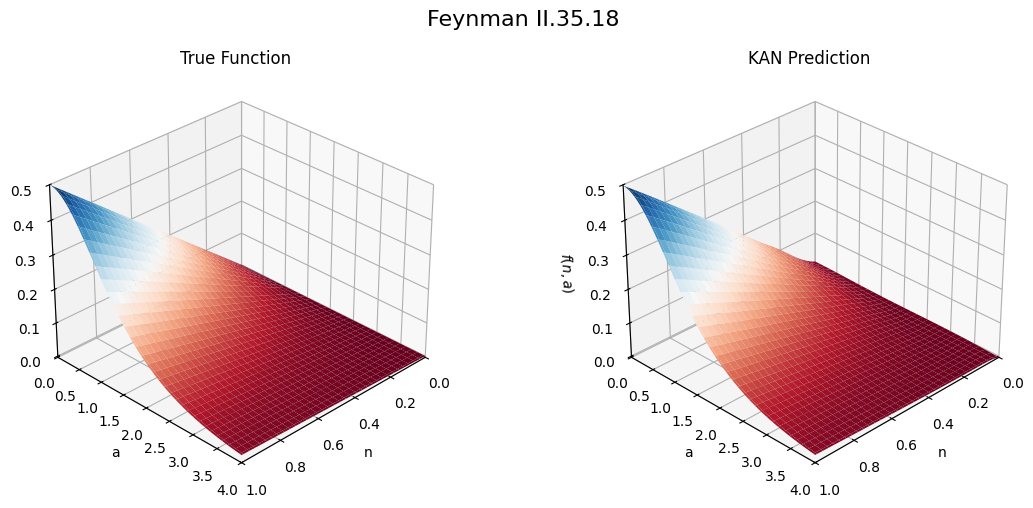

In [139]:
# Plot colormap
fig = plt.figure(figsize=(12,5))

# --- True function ---
ax1 = fig.add_subplot(121, projection='3d')
surf1 = ax1.plot_surface(X1_grid, X2_grid, Z_true, cmap='RdBu')

ax1.set_title("True Function")
ax1.set_xlabel("n")
ax1.set_ylabel("a")

# --- KAN prediction ---
ax2 = fig.add_subplot(122, projection='3d')
surf2 = ax2.plot_surface(X1_grid, X2_grid, Z_pred, cmap='RdBu')

ax2.set_title("KAN Prediction")
ax2.set_xlabel("n")
ax2.set_ylabel("a")
ax2.set_zlabel("$f(n, a)$")

# --- Make axes identical ---
zmin = min(Z_true.min(), Z_pred.min())
zmax = max(Z_true.max(), Z_pred.max())

for ax in [ax1, ax2]:
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 4)
    ax.set_zlim(zmin, zmax)
    ax.view_init(elev=30, azim=45)

plt.suptitle("Feynman II.35.18", fontsize=16)
plt.tight_layout()
plt.show()

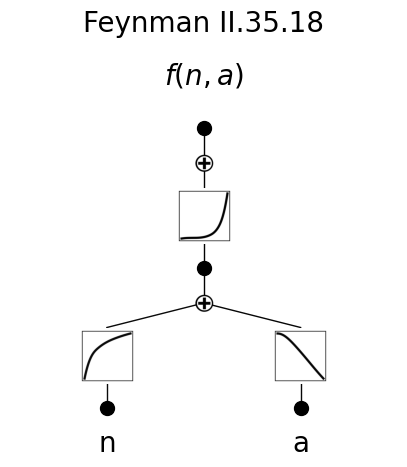

In [140]:
model_II_35_18.plot(in_vars=['n', 'a'], out_vars=['$f(n, a)$'], title="Feynman II.35.18")

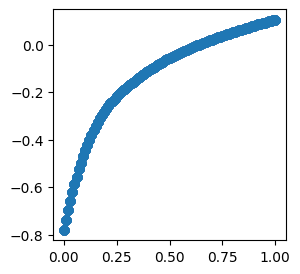

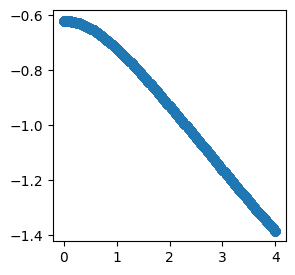

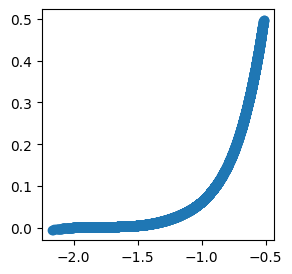

In [141]:
# label: "var_name + #th entry + _in/_out"
n0_in,n0_out = model_II_35_18.get_fun(0,0,0)
a0_in,a0_out = model_II_35_18.get_fun(0,1,0)
# label: "node + #th layer + _#th node + _in/_out"
node1_0_in, node1_0_out = model_II_35_18.get_fun(1,0,0)

In [142]:
os.makedirs("KAN_Feynman_activation_funcs/Feynman_II_35_18", exist_ok=True)
with open("KAN_Feynman_activation_funcs/Feynman_II_35_18/n0.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(n0_in, n0_out)))

with open("KAN_Feynman_activation_funcs/Feynman_II_35_18/a0.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(a0_in, a0_out)))

with open("KAN_Feynman_activation_funcs/Feynman_II_35_18/node1_0.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(node1_0_in, node1_0_out)))

**Feynman II.38.3**

In [143]:
f_II_38_3 = lambda x: x[:,[0]] / (x[:,[1]])
dataset = create_dataset(f_II_38_3, n_var=2, device=device, train_num=100, test_num=100, ranges=[[0, 1], [0.5, 2]])

model_II_38_3 = KAN(width=[2,1,1], grid=3, k=3, seed=1, device=device)

checkpoint directory created: ./model
saving model version 0.0


In [144]:
model_II_38_3.fit(dataset, opt="LBFGS", steps=2000) #lr=1   # or opt="Adam"

| train_loss: 2.42e-03 | test_loss: 2.79e-03 | reg: 5.32e+00 | : 100%|█| 2000/2000 [00:13<00:00, 149


saving model version 0.1


{'train_loss': [array(0.03377723, dtype=float32),
  array(0.02092102, dtype=float32),
  array(0.01767029, dtype=float32),
  array(0.01470499, dtype=float32),
  array(0.01372659, dtype=float32),
  array(0.0104655, dtype=float32),
  array(0.00833493, dtype=float32),
  array(0.00777166, dtype=float32),
  array(0.00743446, dtype=float32),
  array(0.00664483, dtype=float32),
  array(0.00609442, dtype=float32),
  array(0.00523039, dtype=float32),
  array(0.0038015, dtype=float32),
  array(0.00320603, dtype=float32),
  array(0.00290508, dtype=float32),
  array(0.00276738, dtype=float32),
  array(0.00270058, dtype=float32),
  array(0.00268949, dtype=float32),
  array(0.00268083, dtype=float32),
  array(0.00267087, dtype=float32),
  array(0.00285404, dtype=float32),
  array(0.0028292, dtype=float32),
  array(0.0028034, dtype=float32),
  array(0.00277701, dtype=float32),
  array(0.002761, dtype=float32),
  array(0.00280638, dtype=float32),
  array(0.00279002, dtype=float32),
  array(0.00277601, 

In [145]:
a_grid = np.linspace(0, 1, 101)
b_grid = np.linspace(0.5, 2, 101)

X1_grid, X2_grid = np.meshgrid(a_grid, b_grid)

# Convert grid to tensor input
grid_points = torch.tensor(
    np.stack([X1_grid.ravel(), X2_grid.ravel()], axis=1),
    dtype=torch.float32,
    device=device
)

Z_true = f_II_38_3(grid_points).numpy().reshape(X1_grid.shape)

# Get model predictions
with torch.no_grad():       # temporarily disables gradient tracking
    Z_pred = model_II_38_3(grid_points).numpy()
    # use the trained model to predict for the 101x101 grid points

# Reshape to grid
Z_pred = Z_pred.reshape(X1_grid.shape)

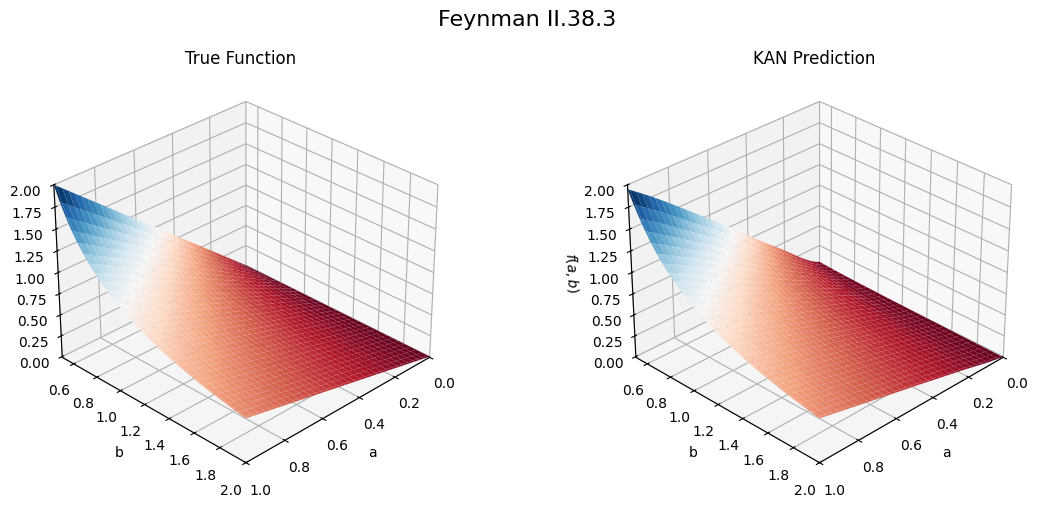

In [146]:
# Plot colormap
fig = plt.figure(figsize=(12,5))

# --- True function ---
ax1 = fig.add_subplot(121, projection='3d')
surf1 = ax1.plot_surface(X1_grid, X2_grid, Z_true, cmap='RdBu')

ax1.set_title("True Function")
ax1.set_xlabel("a")
ax1.set_ylabel("b")

# --- KAN prediction ---
ax2 = fig.add_subplot(122, projection='3d')
surf2 = ax2.plot_surface(X1_grid, X2_grid, Z_pred, cmap='RdBu')

ax2.set_title("KAN Prediction")
ax2.set_xlabel("a")
ax2.set_ylabel("b")
ax2.set_zlabel("$f(a, b)$")

# --- Make axes identical ---
zmin = min(Z_true.min(), Z_pred.min())
zmax = max(Z_true.max(), Z_pred.max())

for ax in [ax1, ax2]:
    ax.set_xlim(0, 1)
    ax.set_ylim(0.5, 2)
    ax.set_zlim(zmin, zmax)
    ax.view_init(elev=30, azim=45)

plt.suptitle("Feynman II.38.3", fontsize=16)
plt.tight_layout()
plt.show()

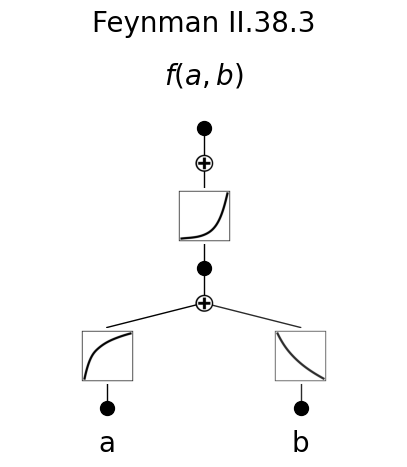

In [147]:
model_II_38_3.plot(in_vars=['a', 'b'], out_vars=['$f(a, b)$'], title="Feynman II.38.3")

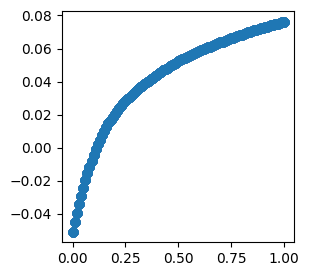

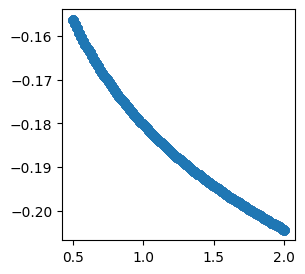

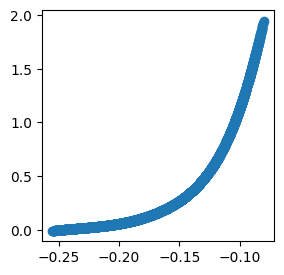

In [148]:
# label: "var_name + #th entry + _in/_out"
a0_in,a0_out = model_II_38_3.get_fun(0,0,0)
b0_in,b0_out = model_II_38_3.get_fun(0,1,0)
# label: "node + #th layer + _#th node + _in/_out"
node1_0_in, node1_0_out = model_II_38_3.get_fun(1,0,0)

In [149]:
os.makedirs("KAN_Feynman_activation_funcs/Feynman_II_38_3", exist_ok=True)
with open("KAN_Feynman_activation_funcs/Feynman_II_38_3/a0.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(a0_in, a0_out)))

with open("KAN_Feynman_activation_funcs/Feynman_II_38_3/b0.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(b0_in, b0_out)))

with open("KAN_Feynman_activation_funcs/Feynman_II_38_3/node1_0.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(node1_0_in, node1_0_out)))

**Feynman III.10.19**

In [150]:
f_III_10_19 = lambda x: torch.sqrt(1 + x[:,[0]]**2 + x[:,[1]]**2)
dataset = create_dataset(f_III_10_19, n_var=2, device=device, train_num=100, test_num=100, ranges=[[0, 1], [0, 1]])

model_III_10_19 = KAN(width=[2,1,1], grid=3, k=3, seed=1, device=device)

checkpoint directory created: ./model
saving model version 0.0


In [151]:
model_III_10_19.fit(dataset, opt="LBFGS", steps=2000) #lr=1   # or opt="Adam"

| train_loss: 2.21e-05 | test_loss: 3.29e-05 | reg: 3.98e+00 | : 100%|█| 2000/2000 [00:14<00:00, 140


saving model version 0.1


{'train_loss': [array(0.01188054, dtype=float32),
  array(0.00454349, dtype=float32),
  array(0.00340966, dtype=float32),
  array(0.00336541, dtype=float32),
  array(0.00335527, dtype=float32),
  array(0.00225566, dtype=float32),
  array(0.00132478, dtype=float32),
  array(0.00117349, dtype=float32),
  array(0.00091567, dtype=float32),
  array(0.00076286, dtype=float32),
  array(0.00068031, dtype=float32),
  array(0.00067385, dtype=float32),
  array(0.00064021, dtype=float32),
  array(0.00058851, dtype=float32),
  array(0.00051097, dtype=float32),
  array(0.0003058, dtype=float32),
  array(0.00028002, dtype=float32),
  array(0.00027727, dtype=float32),
  array(0.00027661, dtype=float32),
  array(0.00027661, dtype=float32),
  array(0.0002552, dtype=float32),
  array(0.00024716, dtype=float32),
  array(0.00023182, dtype=float32),
  array(0.00022462, dtype=float32),
  array(0.00017237, dtype=float32),
  array(7.467383e-05, dtype=float32),
  array(5.425321e-05, dtype=float32),
  array(4.85

In [152]:
a_grid = np.linspace(0, 1, 101)
b_grid = np.linspace(0, 1, 101)

X1_grid, X2_grid = np.meshgrid(a_grid, b_grid)

# Convert grid to tensor input
grid_points = torch.tensor(
    np.stack([X1_grid.ravel(), X2_grid.ravel()], axis=1),
    dtype=torch.float32,
    device=device
)

Z_true = f_III_10_19(grid_points).numpy().reshape(X1_grid.shape)

# Get model predictions
with torch.no_grad():       # temporarily disables gradient tracking
    Z_pred = model_III_10_19(grid_points).numpy()
    # use the trained model to predict for the 101x101 grid points

# Reshape to grid
Z_pred = Z_pred.reshape(X1_grid.shape)

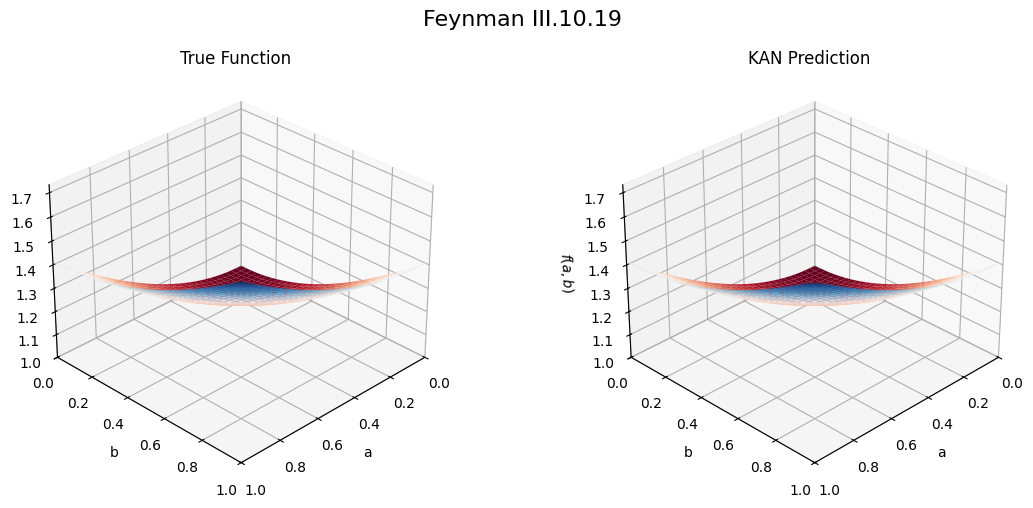

In [153]:
# Plot colormap
fig = plt.figure(figsize=(12,5))

# --- True function ---
ax1 = fig.add_subplot(121, projection='3d')
surf1 = ax1.plot_surface(X1_grid, X2_grid, Z_true, cmap='RdBu')

ax1.set_title("True Function")
ax1.set_xlabel("a")
ax1.set_ylabel("b")

# --- KAN prediction ---
ax2 = fig.add_subplot(122, projection='3d')
surf2 = ax2.plot_surface(X1_grid, X2_grid, Z_pred, cmap='RdBu')

ax2.set_title("KAN Prediction")
ax2.set_xlabel("a")
ax2.set_ylabel("b")
ax2.set_zlabel("$f(a, b)$")

# --- Make axes identical ---
zmin = min(Z_true.min(), Z_pred.min())
zmax = max(Z_true.max(), Z_pred.max())

for ax in [ax1, ax2]:
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_zlim(zmin, zmax)
    ax.view_init(elev=30, azim=45)

plt.suptitle("Feynman III.10.19", fontsize=16)
plt.tight_layout()
plt.show()

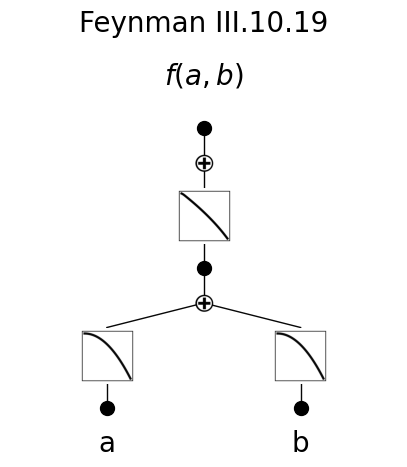

In [154]:
model_III_10_19.plot(in_vars=['a', 'b'], out_vars=['$f(a, b)$'], title="Feynman III.10.19")

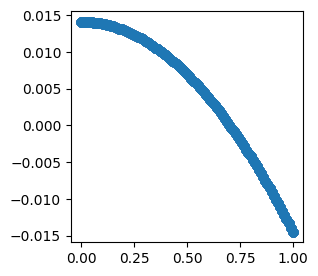

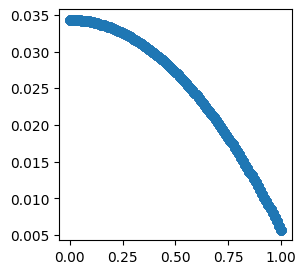

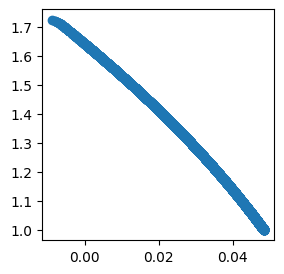

In [155]:
# label: "var_name + #th entry + _in/_out"
a0_in,a0_out = model_III_10_19.get_fun(0,0,0)
b0_in,b0_out = model_III_10_19.get_fun(0,1,0)
# label: "node + #th layer + _#th node + _in/_out"
node1_0_in, node1_0_out = model_III_10_19.get_fun(1,0,0)

In [156]:
os.makedirs("KAN_Feynman_activation_funcs/Feynman_III_10_19", exist_ok=True)
with open("KAN_Feynman_activation_funcs/Feynman_III_10_19/a0.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(a0_in, a0_out)))

with open("KAN_Feynman_activation_funcs/Feynman_III_10_19/b0.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(b0_in, b0_out)))

with open("KAN_Feynman_activation_funcs/Feynman_III_10_19/node1_0.csv", "w") as file:
    file.write("x,f(x)\n")
    file.write("\n".join(f"{x},{y}" for x, y in zip(node1_0_in, node1_0_out)))